1. divide my data to 5 year non-overlapping window in age (people 20-24, 25-29, 30-34 etc.)

2. Per ROI, and per age window, I want to find the slope of birth year (b1)
the regression model is:

for age_window:

GMV_ROI_1 ~ b1*birth_year

3. after calculating all b1 for all age windows, I want to present them in a plot (y axis is GMV, x axisis birth year).

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from tqdm import tqdm
import re
import nibabel as nib
from nilearn.image import new_img_like
from nilearn import plotting
from nilearn.datasets import load_mni152_template
import yabplot as yp

In [2]:
atlas_csv = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv")
# print(f"networks: {atlas_csv['network'].unique()}")
# print(f"compoments: {atlas_csv['component'].unique()}")

In [3]:
# FDR-bug-fixed version: FDR now corrected only across weighting == 'weighted'
# birth_year p-values per window (454 ROIs), instead of pooling weighted +
# unweighted p-values together (908 tests). See step9_refactored_windowing_weighting.ipynb.
coef_df = pd.read_csv('/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/weightedFDRonly_coef_df_manual_bins_wuniform.csv')


In [4]:

# take only interesting bins: (20, 25], (25, 30], (30, 35]
coef_df = coef_df[coef_df['age_bin'].isin(['[20, 25)', '[25, 30)', '[30, 35)'])]

unweighted_birth_year_coef_df = coef_df[
    (coef_df['variable'] == 'birth_year') & (coef_df['weighting'] == 'unweighted')
]
weighted_birth_year_coef_df = coef_df[
    (coef_df['variable'] == 'birth_year') & (coef_df['weighting'] == 'weighted')
]
# rename the column 'index' to 'region_label'
atlas_csv = atlas_csv.rename(columns={'index': 'region_label'})

# add the network and component information to the birth_year_coef_df
unweighted_birth_year_coef_df = unweighted_birth_year_coef_df.merge(atlas_csv[['region_label', 'network', 'component', 'hemisphere']], on='region_label', how='left')
weighted_birth_year_coef_df = weighted_birth_year_coef_df.merge(atlas_csv[['region_label', 'network', 'component', 'hemisphere']], on='region_label', how='left')

In [5]:
birth_year_coef_df = weighted_birth_year_coef_df

birth_year_coef_df['net_comp'] = (
    birth_year_coef_df['network'].astype(str) + "_" + 
    birth_year_coef_df['component'].astype(str)
)

## add stability
1. Load stable rois list that were generated in simulation_based_power_analysis_run.py 
the lists are saved as json files in the data/interim directory
CI (95 or 99) is determined where I create and save the lists (power analysis results.ipynb)
2. add stability column to birth_year_coef_df according to the results of power analysis (True for stable roi)

In [6]:
import json
from pathlib import Path

# 1. Define the base directory
base_dir = Path("/home/gaia/Projects/legacy_data/legacy_pipe/data/interim")

# 2. Define a helper to load and report
def load_roi_list(filename):
    file_path = base_dir / filename
    with open(file_path, "r") as f:
        data = json.load(f)
    print(f"✅ Loaded {len(data):<3} ROIs from: {filename}")
    return data

# 3. Clean loading
early_twenties_roi_list_95 = load_roi_list("stable_95_early_twenties.json")
late_twenties_roi_list_95  = load_roi_list("stable_95_late_twenties.json")
early_thirties_roi_list_95 = load_roi_list("stable_95_early_thirties.json")


# add a 'stable_95' column to birth_year_coef_df with a False default value
birth_year_coef_df['stable_95'] = False

✅ Loaded 173 ROIs from: stable_95_early_twenties.json
✅ Loaded 128 ROIs from: stable_95_late_twenties.json
✅ Loaded 180 ROIs from: stable_95_early_thirties.json


In [7]:
# data type in early_twenties_roi_list_95
print(f"Data type in early_twenties_roi_list_95: {type(early_twenties_roi_list_95)}")
# data type of items in the list 
print(f"Data type of items in early_twenties_roi_list_95: {type(early_twenties_roi_list_95[0])}")

Data type in early_twenties_roi_list_95: <class 'list'>
Data type of items in early_twenties_roi_list_95: <class 'int'>


In [8]:
# fill stable_95
birth_year_coef_df.loc[
    (birth_year_coef_df['age_bin'] == '[20, 25)') & 
    (birth_year_coef_df['region_label'].isin(early_twenties_roi_list_95)), 
    'stable_95'
] = True

birth_year_coef_df.loc[
    (birth_year_coef_df['age_bin'] == '[25, 30)') & 
    (birth_year_coef_df['region_label'].isin(late_twenties_roi_list_95)), 
    'stable_95'
] = True

birth_year_coef_df.loc[
    (birth_year_coef_df['age_bin'] == '[30, 35)') & 
    (birth_year_coef_df['region_label'].isin(early_thirties_roi_list_95)), 
    'stable_95'
] = True


print(f"Any True values in age_bin 20-25? {birth_year_coef_df[birth_year_coef_df['age_bin'] == '[20, 25)']['stable_95'].any()}")
print(f"Any True values in age_bin 25-30? {birth_year_coef_df[birth_year_coef_df['age_bin'] == '[25, 30)']['stable_95'].any()}")
print(f"Any True values in age_bin 30-35? {birth_year_coef_df[birth_year_coef_df['age_bin'] == '[30, 35)']['stable_95'].any()}")

Any True values in age_bin 20-25? True
Any True values in age_bin 25-30? True
Any True values in age_bin 30-35? True


In [9]:
birth_year_coef_df['sig_stab'] = (birth_year_coef_df['fdr_p'] < 0.05) & (birth_year_coef_df['stable_95'] == True)

In [10]:
# save weighted birth_year_coef_df_with_stability (FDR-bug-fixed)
birth_year_coef_df.to_csv("/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/weightedFDRonly_weighted_birth_year_coef_df_with_stability.csv", index=False)

In [11]:
# collecting stats per age_bin (rois that are significant and stable)

stats_list = []
unique_bins = sorted(birth_year_coef_df['age_bin'].unique())

for bin_label in unique_bins:
    # Filter for this bin
    bin_data = birth_year_coef_df[birth_year_coef_df['age_bin'] == bin_label]
    total_rois = bin_data['region_label'].nunique()
    
    # Filter for significant ROIs only
    sig_data = bin_data[bin_data['sig_stab'] == True].copy() # Use .copy() to avoid SettingWithCopyWarning
    num_significant = sig_data.shape[0]
    
    # Calculate percentage
    percentage = (num_significant / total_rois * 100) if total_rois > 0 else 0
    
    if not sig_data.empty:
        sig_net_comp_list = sig_data['net_comp'].unique().tolist()
        sig_roi_names = sig_data['region_name'].tolist()
        sig_roi_label = sig_data['region_label'].tolist()
    else:
        sig_net_comp_list = []
        sig_roi_names = []
        sig_roi_label = []

    print(f"Age Bin: {bin_label}")
    print(f"  Significant: {num_significant}/{total_rois} ({percentage:.2f}%)")

    # Add results to our list
    stats_list.append({
        'age_bin': bin_label,
        'num_significant': num_significant,
        'total_rois': total_rois,
        'percentage': percentage,
        'list_sig_net_comp': sig_net_comp_list, # The new combined column
        'list_sig_rois': sig_roi_names,
        'list_sig_roi_labels': sig_roi_label
    })

# Create the detailed DataFrame
bin_stats_detailed = pd.DataFrame(stats_list)

Age Bin: [20, 25)
  Significant: 173/454 (38.11%)
Age Bin: [25, 30)
  Significant: 128/454 (28.19%)
Age Bin: [30, 35)
  Significant: 179/454 (39.43%)


# Results
using birth_year_coef_df for statistical results (coef, power analysis, significance)
and combined_df for actual gmv per roi per scan

In [12]:
# --- Find repeating Network+Component combinations ---
# explode() expands the lists into individual rows
all_sig_net_comp = bin_stats_detailed['list_sig_net_comp'].explode()
net_comp_counts = all_sig_net_comp.value_counts()


# print("\nNetwork + Component combinations that appear in multiple age bins:")
# for combo, count in net_comp_counts.items():
#     if count > 1:
#         print(f"  {combo}: appears in {count} age bins")

# find the rois that appear in multiple age bins
all_sig_rois = bin_stats_detailed['list_sig_rois'].explode()
roi_counts = all_sig_rois.value_counts()

print("\nROIs that appear in multiple age bins:")
for roi, count in roi_counts.items():
    if count > 1:
        print(f"  {roi}: appears in {count} age bins")

# roi_count = number of age bins where each ROI is significant AND stable
sig_stable_counts = (
    birth_year_coef_df[birth_year_coef_df['sig_stab'] == True]
    .groupby('region_name')['age_bin']
    .nunique()
)
birth_year_coef_df['roi_count'] = birth_year_coef_df['region_name'].map(sig_stable_counts).fillna(0).astype(int)


ROIs that appear in multiple age bins:
  7Networks_LH_SomMot_1: appears in 3 age bins
  7Networks_LH_SomMot_2: appears in 3 age bins
  7Networks_LH_SomMot_3: appears in 3 age bins
  7Networks_LH_SomMot_4: appears in 3 age bins
  7Networks_LH_SomMot_5: appears in 3 age bins
  7Networks_LH_SomMot_8: appears in 3 age bins
  7Networks_LH_SomMot_9: appears in 3 age bins
  7Networks_LH_SomMot_10: appears in 3 age bins
  7Networks_LH_SomMot_34: appears in 3 age bins
  7Networks_LH_SomMot_36: appears in 3 age bins
  7Networks_LH_SalVentAttn_FrOperIns_1: appears in 3 age bins
  7Networks_LH_SalVentAttn_FrOperIns_2: appears in 3 age bins
  7Networks_LH_SalVentAttn_FrOperIns_3: appears in 3 age bins
  7Networks_LH_SalVentAttn_FrOperIns_4: appears in 3 age bins
  7Networks_LH_SalVentAttn_FrOperIns_5: appears in 3 age bins
  7Networks_LH_SalVentAttn_FrOperIns_6: appears in 3 age bins
  7Networks_LH_SalVentAttn_FrOperIns_7: appears in 3 age bins
  7Networks_LH_SalVentAttn_FrOperIns_8: appears in 3 

# Visualization

In [13]:
# age_bin interval and median for plotting over age_bins

def string_to_interval(interval_str):
    if pd.isna(interval_str) or not isinstance(interval_str, str):
        return None
    # Remove brackets/parentheses and split by the dash
    # Note: This assumes your ages are always positive!
    clean_str = interval_str.strip("()[] ")
    # split by - or , 
    if "-" in clean_str:
        left, right = clean_str.split("-", 1)
    else:
        left, right = clean_str.split(",", 1)
    return pd.Interval(float(left), float(right), closed='left')

# 1. Convert strings to Interval objects
birth_year_coef_df['age_bin_interval'] = birth_year_coef_df['age_bin'].apply(string_to_interval)

birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['age_bin_interval'].apply(lambda x: x.mid)

In [14]:
print(birth_year_coef_df.columns)

Index(['age_bin', 'region_label', 'variable', 'weighting', 'coef', 't', 'p',
       'n_subjects', 'ess', 'index', 'region_name', 'fdr_p', 'network',
       'component', 'hemisphere', 'net_comp', 'stable_95', 'sig_stab',
       'roi_count', 'age_bin_interval', 'mid_age_bin'],
      dtype='str')


# Visualizations on the brain

### Stable, significant ROIs per age_bin

Processing age bin: [20, 25)


2026-08-10 14:52:46.237 (   0.994s) [    7C4D9CC7B080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


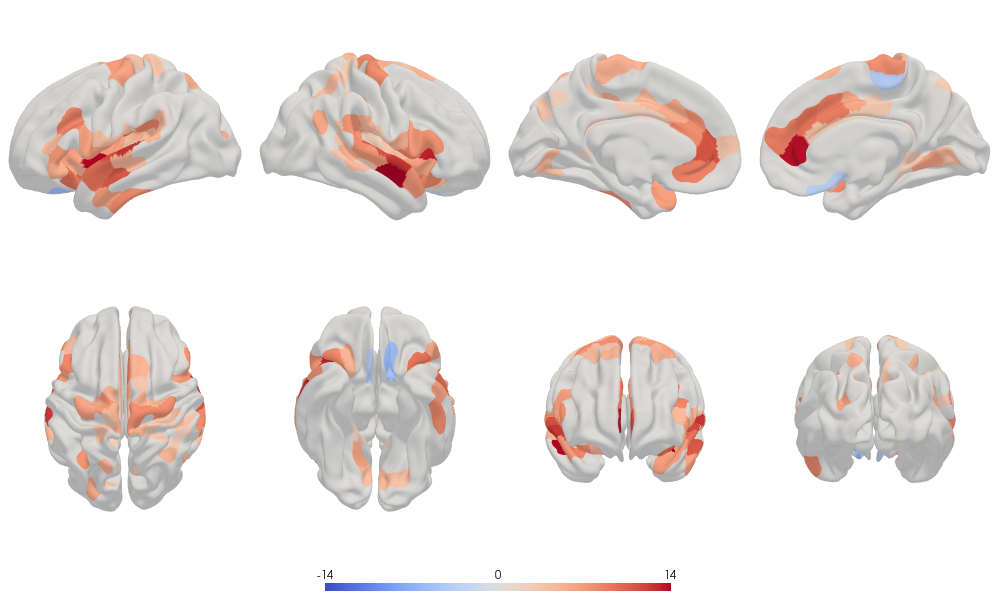

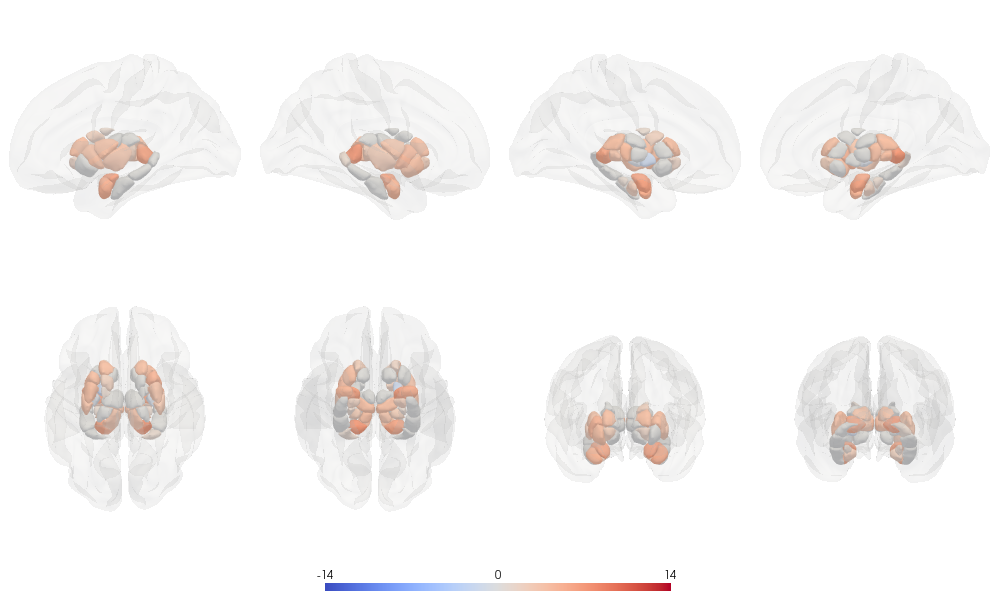

Processing age bin: [25, 30)


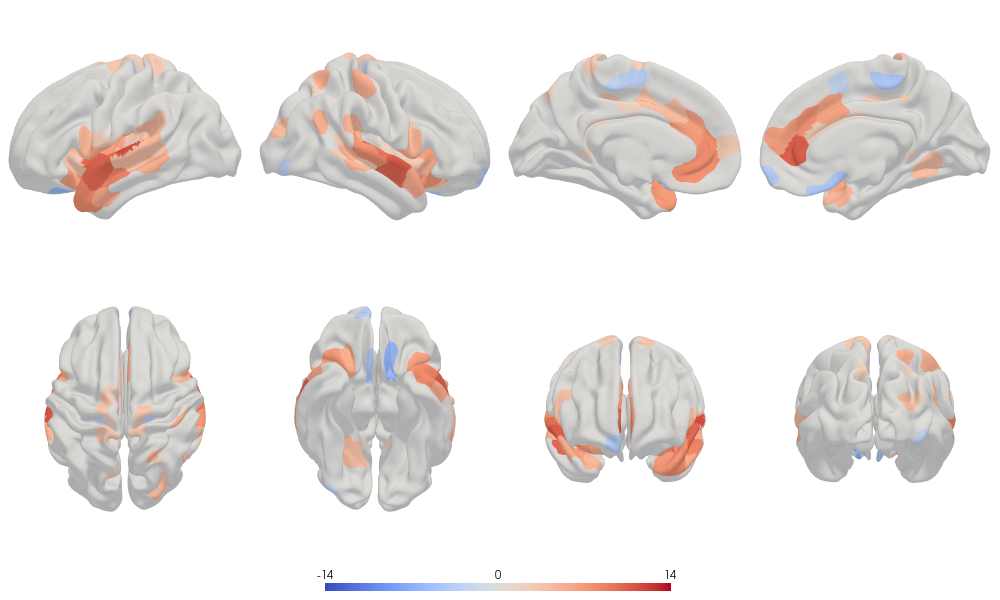

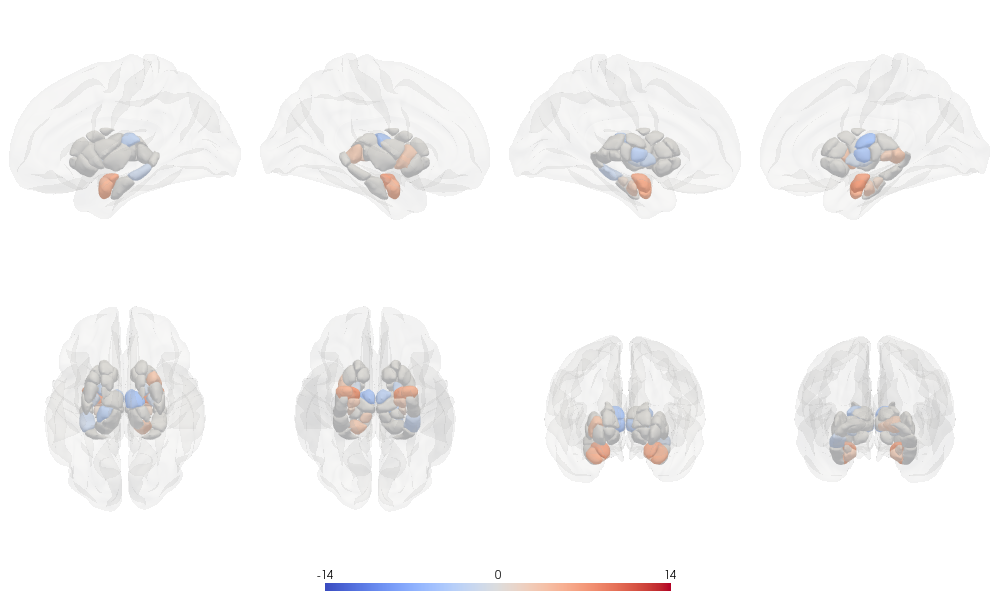

Processing age bin: [30, 35)


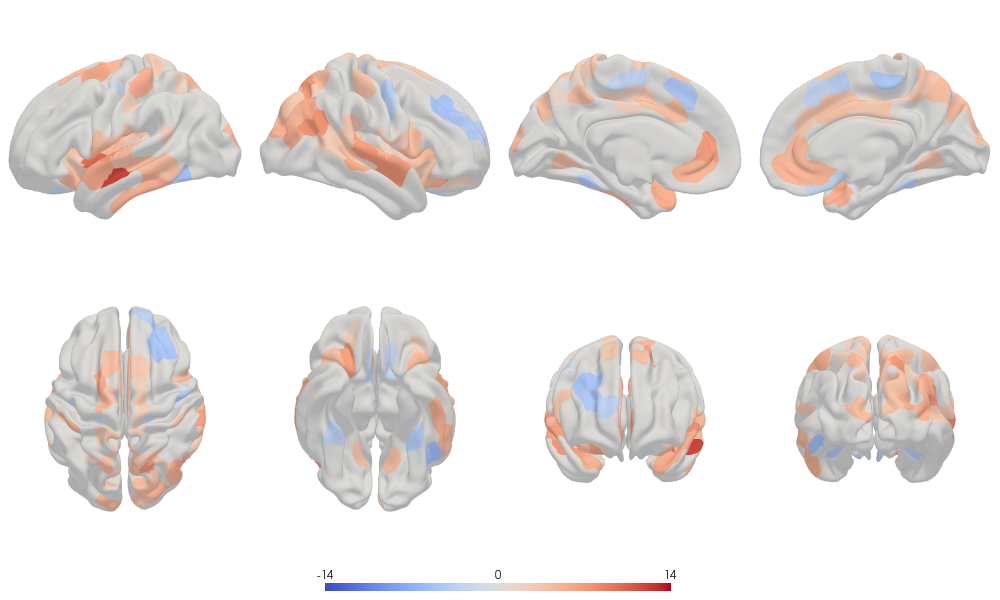

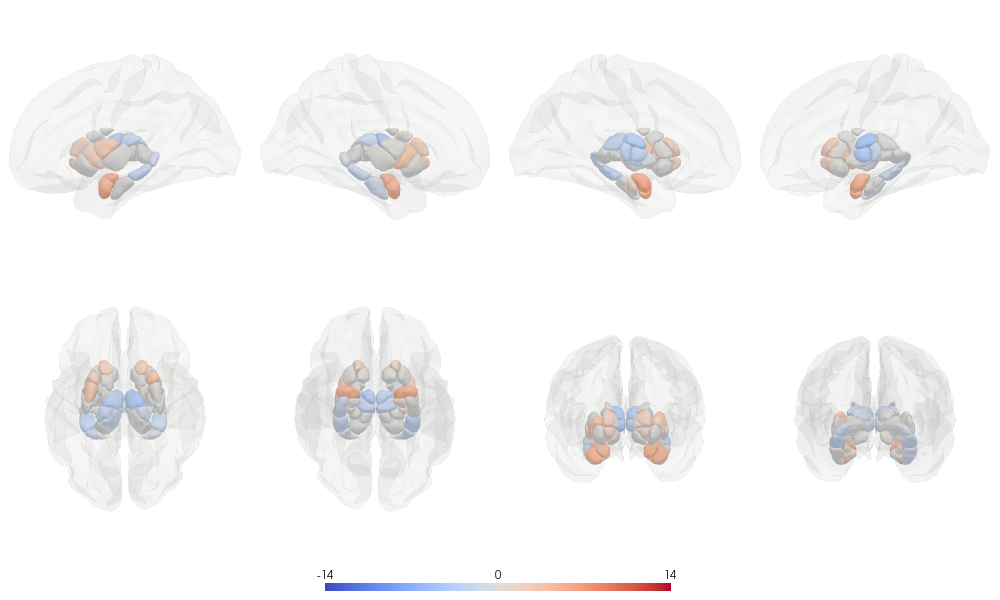

In [15]:
import numpy as np
import pandas as pd
import yabplot as yp # Using yp consistently

# Path to the meshes you built in the script above
SUB_ATLAS_PATH = '/home/gaia/Projects/legacy_data/legacy_pipe/models/atlases/subcortical/tian2020_s7'

# ── Step 1: Filter Significant & Stable ROIs ────────────────────────────────
for age_bin in birth_year_coef_df['age_bin'].unique():
    print(f'Processing age bin: {age_bin}')
    age_bin_data = birth_year_coef_df[birth_year_coef_df['age_bin'] == age_bin]

    # Initialize dict for all regions in this bin
    all_regions = age_bin_data['region_name'].unique()
    coef_dict = {region: np.nan for region in all_regions}
    
    # Filter for stable and significant
    bin_sig_stable_df = age_bin_data[age_bin_data['sig_stab'] == True]

    for _, row in bin_sig_stable_df.iterrows():
        coef_dict[row['region_name']] = row['coef']

    # Split data for cortical/subcortical plotting
    cortical_data = {k: v for k, v in coef_dict.items() if k.startswith('7Networks_')}
    subcortical_data = {k: v for k, v in coef_dict.items() if not k.startswith('7Networks_')}

    # ── Step 2: Plot ─────────────────────────────────────────────────────────
    # Cortical (Schaefer)
    yp.plot_cortical(
        data=cortical_data,
        atlas='schaefer400',
        vminmax=[-14, 14],
        nan_color=(0.85, 0.85, 0.85),
        display_type='static',
    )

    # Subcortical (Tian - loaded from your saved path)
    yp.plot_subcortical(
        data=subcortical_data,
        custom_atlas_path=SUB_ATLAS_PATH,
        vminmax=[-14, 14],
        nan_color=(0.85, 0.85, 0.85),
        display_type='static',
    )

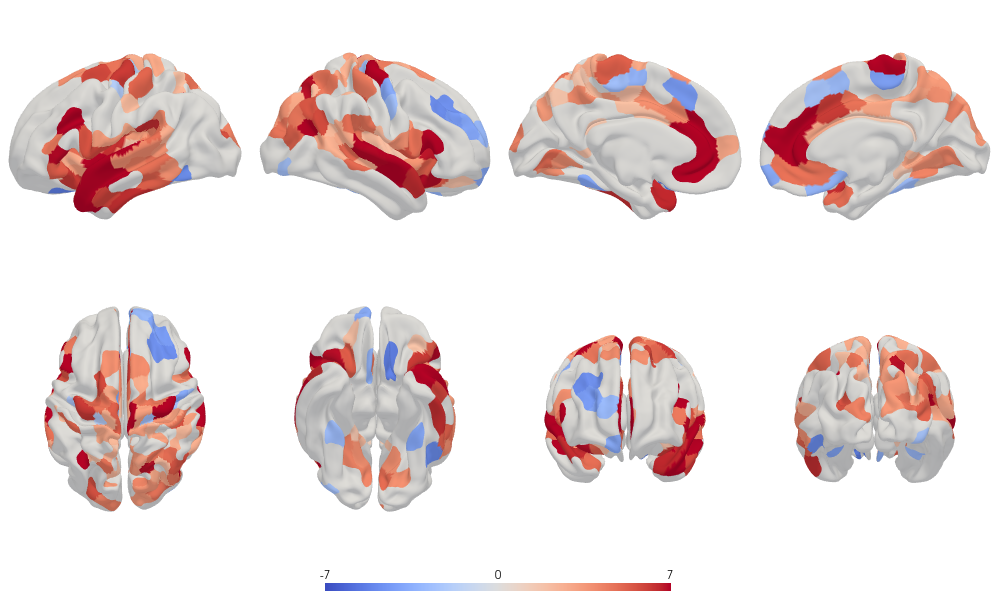

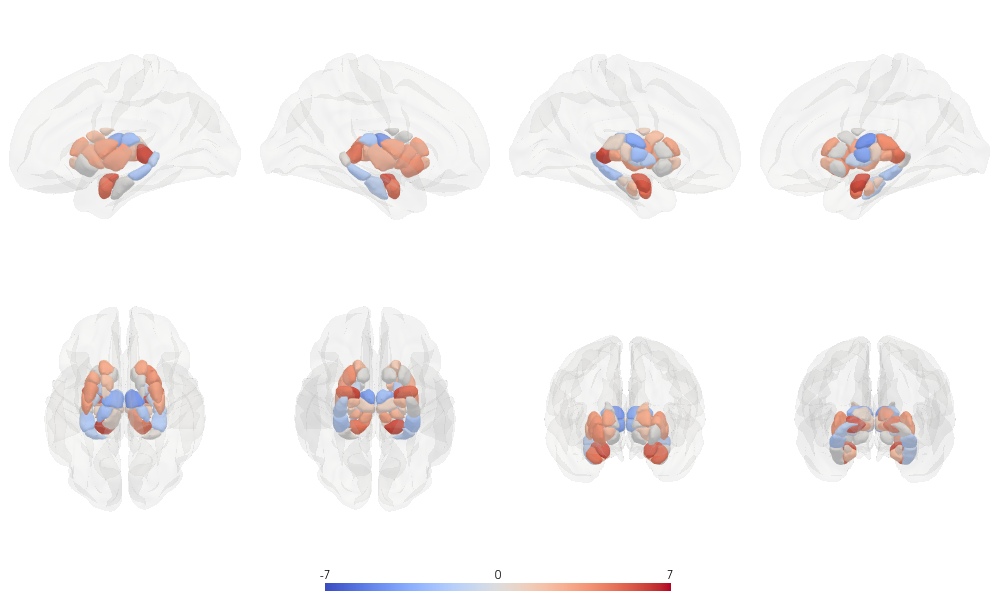

In [16]:
# ── Step 1: Filter Significant & Stable ROIs ────────────────────────────────
sig_stable_df = birth_year_coef_df[
    birth_year_coef_df['sig_stab'] == True
]

# >>> ADD THE MEDIAN AGGREGATION HERE <<<
# This collapses multiple age-bin coefficients into one median value per ROI
median_coefs = sig_stable_df.groupby('region_name')['coef'].median().to_dict()

# ── Step 2: Split Data for Plotting ─────────────────────────────────────────
# Use the new 'median_coefs' dictionary instead of the raw dataframe
cortical_data = {k: v for k, v in median_coefs.items() if k.startswith('7Networks_')}
subcortical_data = {k: v for k, v in median_coefs.items() if not k.startswith('7Networks_')}

# ── Step 3: Plot ─────────────────────────────────────────────────────────
# Cortical (Schaefer)
yp.plot_cortical(
    data=cortical_data,
    atlas='schaefer400',
    vminmax=[-7, 7],
    nan_color=(0.85, 0.85, 0.85),
    display_type='static',
)

# Subcortical (Tian)
yp.plot_subcortical(
    data=subcortical_data,
    custom_atlas_path=SUB_ATLAS_PATH,
    vminmax=[-7, 7],
    nan_color=(0.85, 0.85, 0.85),
    display_type='static',
)

## significant, stable ROIs repeating in age bins


Generating Aggregate Stability Plots...


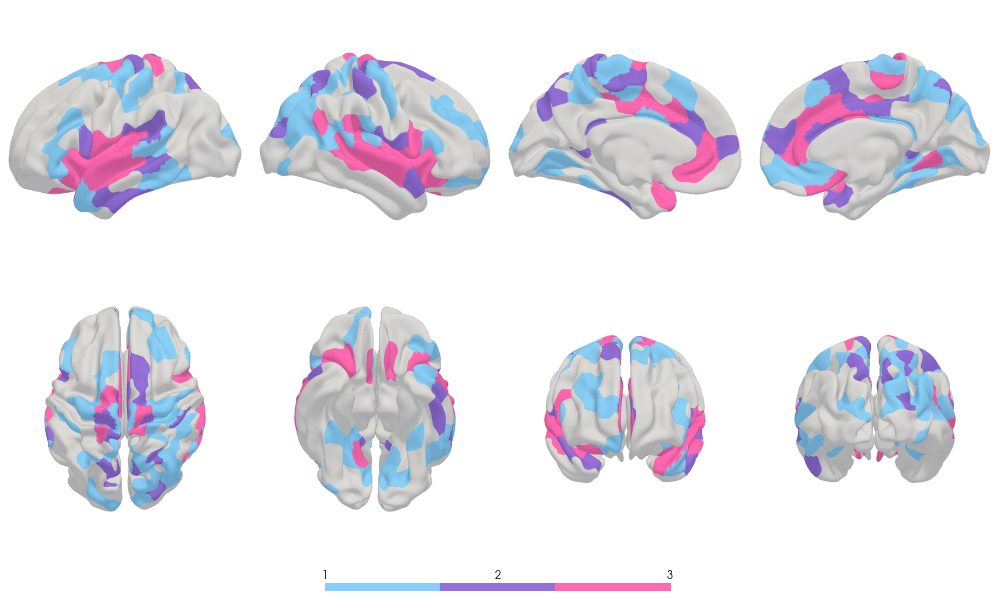

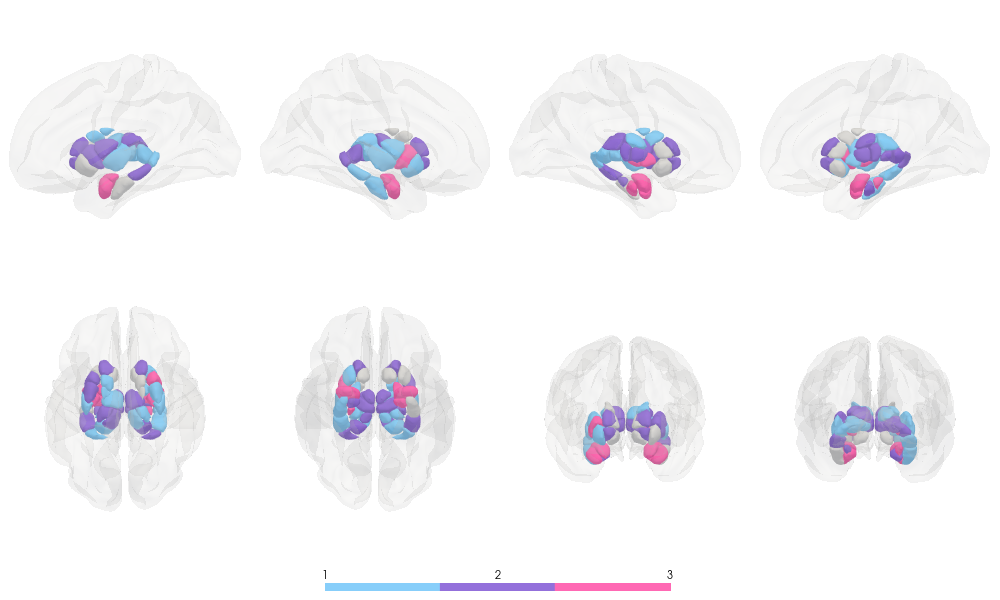

In [17]:
import numpy as np
from matplotlib.colors import ListedColormap

# --- 1. Prepare plot dict from roi_count (already on birth_year_coef_df) ---

# 1. Define your discrete colors (one for each count: 1, 2, and 3)
# You can use specific hex codes or pull from Set3
categorical_colors = ["lightskyblue", "mediumpurple", "hotpink"] # Example Set3 colors
custom_cmap = ListedColormap(categorical_colors)

# roi_count == 0 means never sig+stable -> gray (nan) in the plot
roi_count_per_region = (
    birth_year_coef_df.drop_duplicates('region_name')
    .set_index('region_name')['roi_count']
)
plot_dict = {r: (float(c) if c > 0 else np.nan) for r, c in roi_count_per_region.items()}

# Split into Cortical and Subcortical
cortical_data = {k: v for k, v in plot_dict.items() if k.startswith('7Networks_')}
subcortical_data = {k: v for k, v in plot_dict.items() if not k.startswith('7Networks_')}


# --- 5. Generate the Final Plots (One for Cortex, One for Subcortex) ---

print("\nGenerating Aggregate Stability Plots...")

# Cortical Plot (Schaefer 400)
yp.plot_cortical(
    data=cortical_data,
    atlas='schaefer400',
    vminmax=[1, 3], # 1 = appears once, 3 = appears in 3+ bins
    cmap = custom_cmap,
    nan_color=(0.85, 0.85, 0.85), # Light gray for non-significant/unstable
    display_type='static',
)

# Subcortical Plot (Tian)
yp.plot_subcortical(
    data=subcortical_data,
    custom_atlas_path=SUB_ATLAS_PATH,
    vminmax=[1, 3],
    cmap = custom_cmap,
    nan_color=(0.85, 0.85, 0.85),
    display_type='static',
)

# Visualize coefficient trends per ROI (significant and stable)

In [18]:
# ── ROI count filter ────────────────────────────────────────────────────────
# Change MIN_ROI_COUNT to control which ROIs are included downstream:
#   1 = sig+stable in at least 1 age bin
#   2 = sig+stable in at least 2 age bins
#   3 = sig+stable in all 3 age bins
MIN_ROI_COUNT = 3

sig_stable_df = birth_year_coef_df[
    (birth_year_coef_df['sig_stab'] == True) &
    (birth_year_coef_df['roi_count'] >= MIN_ROI_COUNT)
].copy()

combined_df = pd.read_pickle("/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/combined_df_with_weights_per_window.pkl")

print(f"MIN_ROI_COUNT = {MIN_ROI_COUNT}  ->  {sig_stable_df['region_name'].nunique()} unique ROIs, {len(sig_stable_df)} rows")


MIN_ROI_COUNT = 3  ->  81 unique ROIs, 243 rows


In [19]:
# # PLOT COEF TRENDS PER ROI OVER AGE_BINS

# # # Your specific ROIs
# # roi_list = [421, 422, 448, 449]

# roi_list = sig_stable_df['region_label'].unique().tolist()


# for region_of_interest in roi_list:
#     # Filter data for the specific ROI
#     region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest].copy()
    
#     if region_data.shape[0] < 2:
#         print(f"Not enough data points for region {region_of_interest} to plot.")
#         continue
    
#     # 2. Plotting
#     plt.figure(figsize=(7, 4))
    
#     # Draw the gray connecting line first (to show the raw sequence)
#     sns.lineplot(
#         data=region_data,
#         x='mid_age_bin',
#         y='coef',
#         color='lightsteelblue',
#         zorder=1,
#         legend=False
#     )
    
#     # Draw coefficients as consistent markers
#     sns.scatterplot(
#         data=region_data,
#         x='mid_age_bin',
#         y='coef',
#         color='cornflowerblue',
#         marker='o',
#         s=70,
#         zorder=2,
#         label='Birth Year Coef (β)'
#     )

#     # Aesthetics
#     plt.axhline(0, color='black', lw=0.8, ls='--') # Baseline at zero
#     plt.title(f'Birth Year Coefficient Trend: Region {region_of_interest}', fontsize=12)
#     plt.xlabel('Mid-Age of Window (Years)')
#     plt.ylabel('Birth Year Coefficient (β)')
    
#     # Clean up legend
#     plt.legend(loc='best', fontsize='small')
    
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()

In [20]:
# are there components or networks where ALL ROIs meet MIN_ROI_COUNT?

# add roi_count (sig+stable bin count) to atlas_csv
atlas_csv['roi_count'] = atlas_csv['name'].map(sig_stable_counts)
atlas_csv['network_component'] = atlas_csv['network'] + '_' + atlas_csv['component']

# 1. Find components where ALL ROIs have roi_count >= MIN_ROI_COUNT
fully_qualified_components = atlas_csv.groupby('network_component')['roi_count'].transform(lambda x: (x >= MIN_ROI_COUNT).all())
component_names = atlas_csv[fully_qualified_components]['network_component'].unique()

if len(component_names) > 0:
    print(f"Components where ALL ROIs have roi_count >= {MIN_ROI_COUNT}:")
    for name in sorted(component_names):
        print(f"  {name}")
else:
    print(f"No component has all ROIs with roi_count >= {MIN_ROI_COUNT}")

# 2. Find networks where ALL ROIs have roi_count >= MIN_ROI_COUNT
fully_qualified_networks = atlas_csv.groupby('network')['roi_count'].transform(lambda x: (x >= MIN_ROI_COUNT).all())
network_names = atlas_csv[fully_qualified_networks]['network'].unique()

if len(network_names) > 0:
    print(f"\nNetwork names where ALL ROIs have roi_count >= {MIN_ROI_COUNT}:")
    for name in sorted(network_names):
        print(f"  {name}")
else:
    print(f"No network has all ROIs with roi_count >= {MIN_ROI_COUNT}")

Components where ALL ROIs have roi_count >= 3:
  control_ventral prefrontal cortex
  subcortex_Amygdala
No network has all ROIs with roi_count >= 3


In [21]:
# plot setting: 
main_title_fontsize = 80
subtitle_fontsize = 70
axis_label_fontsize = 74
ticks_fontsize = 50
legend_fontsize = 42

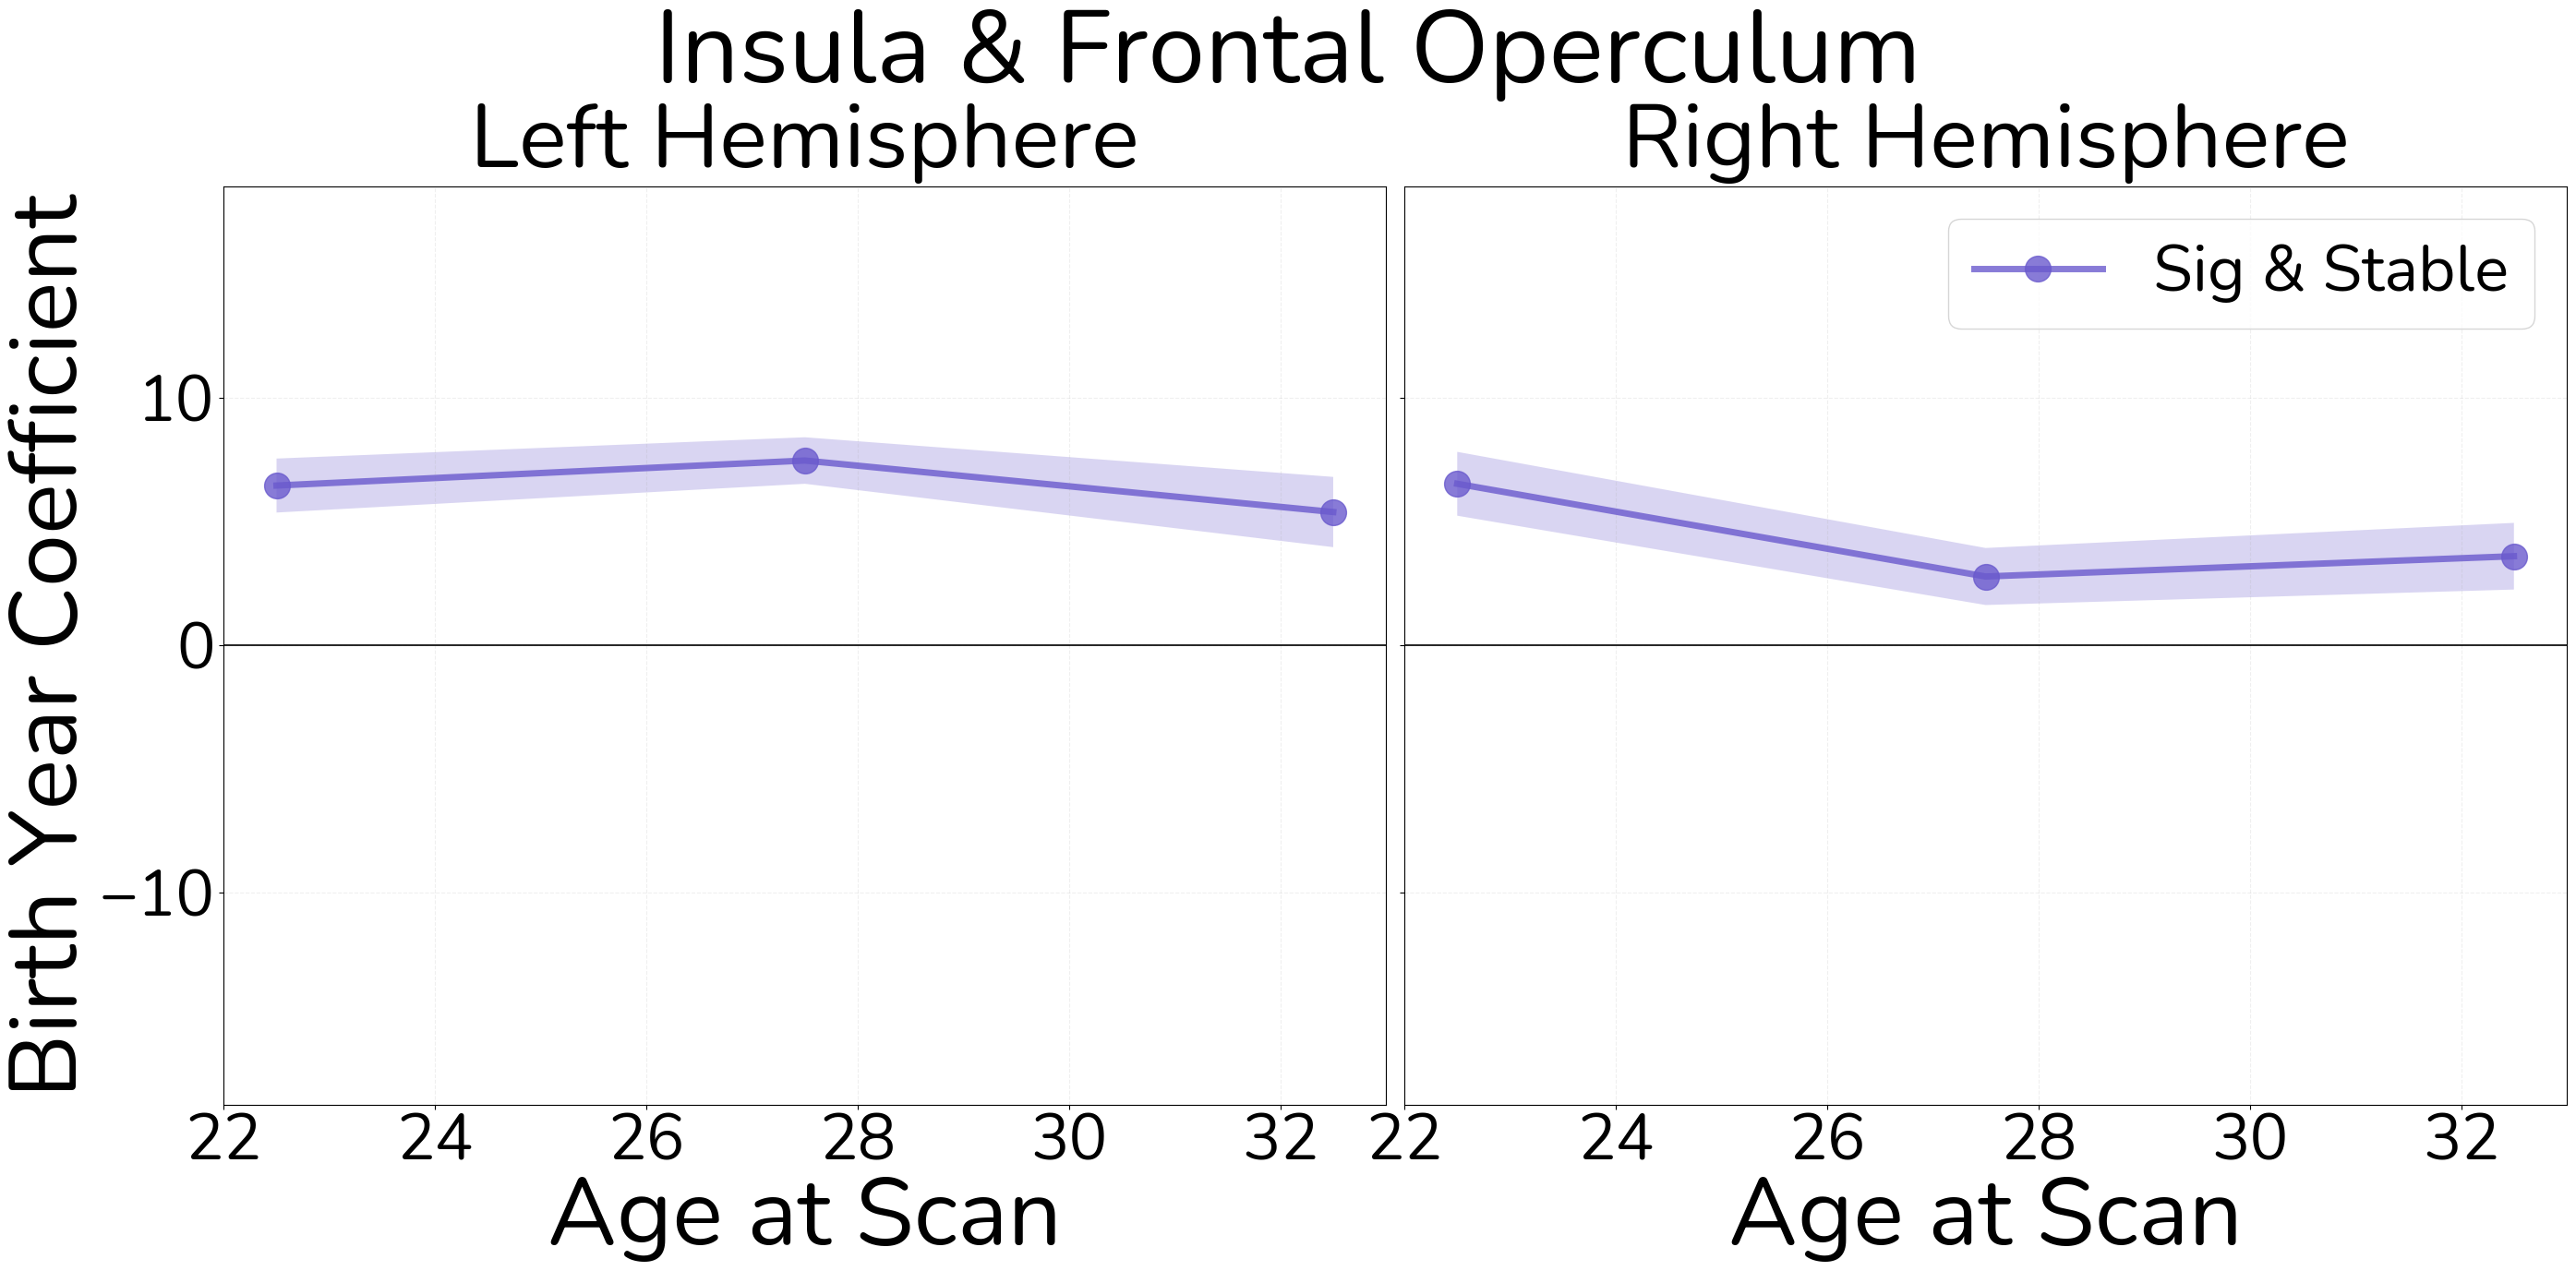

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from scipy import stats

# --- 1. CI Calculation ---
# Filter for weighted data as established in your workflow
df_plot = birth_year_coef_df[birth_year_coef_df['weighting'] == 'weighted'].copy()

# Calculate Standard Error (SE)
df_plot['se'] = df_plot['coef'] / df_plot['t'].abs()

def calculate_ci_bounds(row):
    # Degrees of freedom: Effective sample size (ess) - number of predictors (approx 5)
    df_val = max(row['ess'] - 5, 1) 
    crit_t = stats.t.ppf(0.975, df_val)
    margin = crit_t * row['se']
    return row['coef'] - margin, row['coef'] + margin

# Generate the low and high bounds for the CI shading
df_plot[['conf_low', 'conf_high']] = df_plot.apply(
    lambda x: calculate_ci_bounds(x), axis=1, result_type='expand'
)

# --- 2. Font Setup ---
font_path = '/home/gaia/Downloads/Nunito/static/Nunito-Regular.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Nunito', 'sans-serif']
plt.rcParams['text.antialiased'] = True

# --- 3. Plotting Setup ---
# Calculate symmetric limit including the CI bounds to avoid clipping
max_val = max(df_plot['conf_high'].max(), df_plot['conf_low'].abs().max())
y_limit = max_val * 1.1 

hemispheres = {
    'Left Hemisphere': [97],
    'Right Hemisphere': [303]
}

color_map = {
    'Sig & Stable': "slateblue", 
    'Other': "slategray"         
}

fig, axes = plt.subplots(1, 2, figsize=(28, 14), sharey=True)
fig.suptitle('Insula & Frontal Operculum', fontsize=main_title_fontsize, fontweight='bold')

for i, (hemi_name, rois) in enumerate(hemispheres.items()):
    ax = axes[i]
    
    # Filter data for this hemisphere
    hemi_data = df_plot[df_plot['region_label'].isin(rois)].copy()
    
    if hemi_data.empty:
        ax.set_title(f"{hemi_name} (No Data)")
        continue

    # Create the coloring strategy column
    hemi_data['status'] = 'Other'
    hemi_data.loc[hemi_data['sig_stab'] == True, 'status'] = 'Sig & Stable'

    # --- THE FIX: Explicitly loop through statuses to ensure all CIs are drawn ---
    for status_label in color_map.keys():
        status_subset = hemi_data[hemi_data['status'] == status_label].sort_values('mid_age_bin')
        
        if not status_subset.empty:
            # A. Draw the shaded Confidence Interval
            ax.fill_between(
                status_subset['mid_age_bin'],
                status_subset['conf_low'],
                status_subset['conf_high'],
                color=color_map[status_label],
                alpha=0.25,        
                edgecolor=None,
                zorder=1           # Place behind the lines
            )
            
            # B. Draw the Mean Line and markers
            ax.plot(
                status_subset['mid_age_bin'],
                status_subset['coef'],
                color=color_map[status_label],
                marker='o',
                markersize=20,
                linewidth=5,
                label=status_label,
                alpha=0.8,
                zorder=2           # Place in front of the shades
            )

    # Aesthetics
    ax.axhline(0, color='black', lw=1.2, ls='-')
    ax.set_ylim(-y_limit, y_limit)
    ax.set_title(hemi_name, fontsize=subtitle_fontsize, fontweight='bold', pad=15)
    ax.set_xlabel('Age at Scan', fontsize=axis_label_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=ticks_fontsize)
    
    if i == 0:
        ax.set_ylabel('Birth Year Coefficient', fontsize=axis_label_fontsize)
    
    ax.grid(True, alpha=0.2, linestyle='--')
    
    # Show legend only on the right plot
    if i == 1:
        ax.legend(loc='best', frameon=True, fontsize=ticks_fontsize)
    else:
        ax.get_legend().remove() if ax.get_legend() else None

plt.tight_layout()
plt.show()

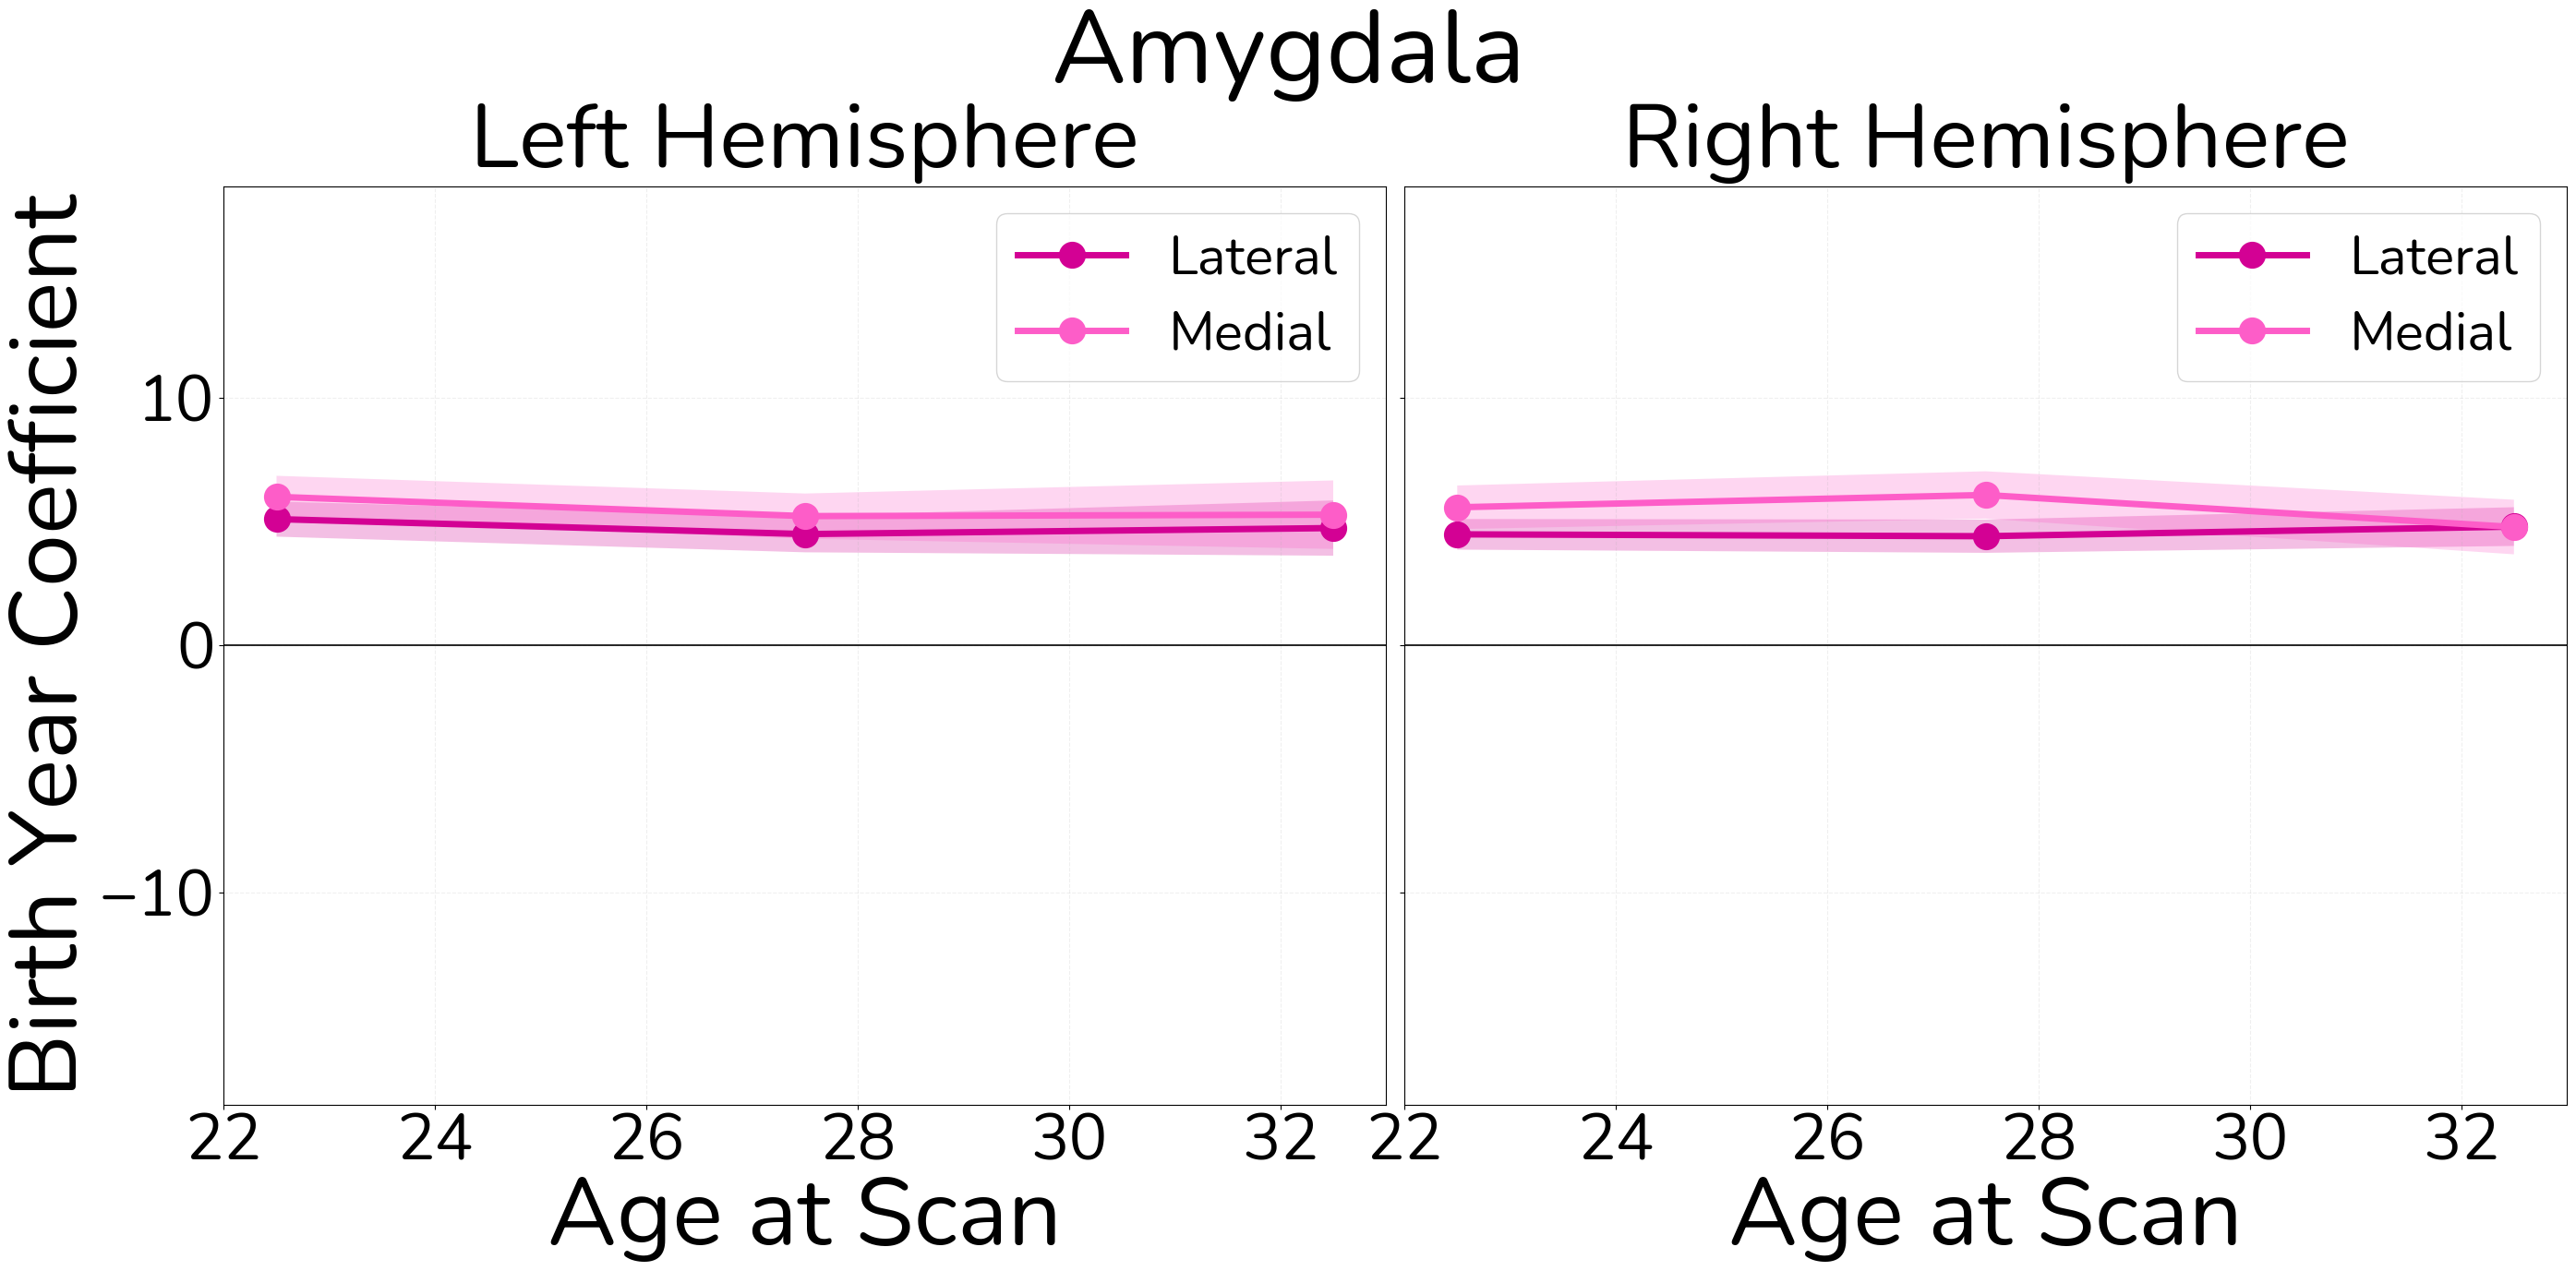

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from scipy import stats

# --- 1. CI Calculation & Filtering ---
# Ensure we are using the weighted data
df_weighted = birth_year_coef_df[birth_year_coef_df['weighting'] == 'weighted'].copy()

# Calculate Standard Error (SE) using absolute t-values
df_weighted['se'] = df_weighted['coef'] / df_weighted['t'].abs()

def calculate_bounds(row):
    # Degrees of freedom: Effective sample size (ess) - predictors
    # Assuming 5 predictors based on your model (Age, Sex, TIV, Birth Year, intercept)
    df = max(row['ess'] - 5, 1) 
    crit_t = stats.t.ppf(0.975, df)
    margin_of_error = crit_t * row['se']
    return row['coef'] - margin_of_error, row['coef'] + margin_of_error

# Apply CI calculation
df_weighted[['conf_low', 'conf_high']] = df_weighted.apply(
    lambda x: calculate_bounds(x), axis=1, result_type='expand'
)

# --- 2. Font Setup ---
font_path = '/home/gaia/Downloads/Nunito/static/Nunito-Regular.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Nunito', 'sans-serif']
plt.rcParams['text.antialiased'] = True

# --- 3. Plotting Setup ---
# Calculate symmetric limit including the CI bounds
max_val = max(df_plot['conf_high'].max(), df_plot['conf_low'].abs().max())
y_limit = max_val * 1.1 

hemispheres = {
    'Left Hemisphere': [448, 449],
    'Right Hemisphere': [421, 422]
}

roi_label_map = {421: "Lateral", 422: "Medial", 448: "Lateral", 449: "Medial"}
roi_colors = {"Lateral": "#d30194", "Medial": "#fd5dc8"}

fig, axes = plt.subplots(1, 2, figsize=(28, 14), sharey=True)
fig.suptitle('Amygdala', fontsize=main_title_fontsize, fontweight='bold')

for i, (hemi_name, rois) in enumerate(hemispheres.items()):
    ax = axes[i]
    
    # Filter and Map Data for this specific hemisphere
    hemi_data = df_plot[df_plot['region_label'].isin(rois)].copy()
    hemi_data['roi_display_name'] = hemi_data['region_label'].map(roi_label_map)
    
    if hemi_data.empty:
        ax.set_title(f"{hemi_name} (No Data)")
        continue

    # --- THE FIX: Explicitly loop through each ROI in the hemisphere ---
    # This ensures both Lateral and Medial get their own CI shading
    for roi_name in hemi_data['roi_display_name'].unique():
        roi_subset = hemi_data[hemi_data['roi_display_name'] == roi_name].sort_values('mid_age_bin')
        
        # 1. Shaded CI area
        ax.fill_between(
            roi_subset['mid_age_bin'],
            roi_subset['conf_low'],
            roi_subset['conf_high'],
            color=roi_colors[roi_name],
            alpha=0.25,        
            edgecolor=None,
            zorder=1           # Ensure shading is behind lines
        )
        
        # 2. Mean line and markers
        ax.plot(
            roi_subset['mid_age_bin'],
            roi_subset['coef'],
            color=roi_colors[roi_name],
            marker='o',
            markersize=20,
            linewidth=5,
            label=roi_name,    # This feeds the legend
            zorder=2
        )

    # Aesthetics
    ax.set_ylim(-y_limit, y_limit)
    ax.axhline(0, color='black', lw=1.2, ls='-')
    ax.set_title(hemi_name, fontsize=subtitle_fontsize, fontweight='bold', pad=15)
    ax.set_xlabel('Age at Scan', fontsize=axis_label_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=ticks_fontsize)

    if i == 0:
        ax.set_ylabel('Birth Year Coefficient', fontsize=axis_label_fontsize)

    ax.grid(True, alpha=0.2, linestyle='--')
    ax.legend(loc='best', frameon=True, fontsize=legend_fontsize)

plt.tight_layout()
plt.show()

# plot specific for amygdala

In [24]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib.font_manager as fm

# # 1. Point to the file you just downloaded
# font_path = '/home/gaia/Downloads/Nunito/static/Nunito-Regular.ttf' # Example path
# fm.fontManager.addfont(font_path)

# # 2. Set it globally
# plt.rcParams['font.family'] = 'Nunito'
# # Set Nunito as the primary sans-serif font
# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Nunito',  'sans-serif']

# # Optional: Improve font rendering for high-res displays
# plt.rcParams['text.antialiased'] = True

# # 1. Calculate the symmetric limit based on the data
# # We find the maximum absolute value of the 'coef' column to ensure 0 is centered
# max_abs_coef = birth_year_coef_df['coef'].abs().max()
# y_limit = max_abs_coef  

# # Reordered: Left Hemisphere first so it maps to axes[0]
# hemispheres = {
#     'Left Hemisphere': [448, 449],
#     'Right Hemisphere': [421, 422]
# }

# # Mapping to clean legend labels
# roi_label_map = {
#     421: "Lateral",
#     422: "Medial",
#     448: "Lateral",
#     449: "Medial"
# }

# # Colors for clean labels
# roi_colors = {
#     "Lateral": "#ff0eb7", 
#     "Medial": "#f7a7dc"
# }

# # Adjusted figsize for standard high-res viewing
# fig, axes = plt.subplots(1, 2, figsize=(28, 14), sharey=True)
# fig.suptitle('Amygdala', fontsize=main_title_fontsize, fontweight='bold')

# for i, (hemi_name, rois) in enumerate(hemispheres.items()):
#     ax = axes[i]
    
#     # Filter and Map Data
#     hemi_data = birth_year_coef_df[birth_year_coef_df['region_label'].isin(rois)].copy()
#     hemi_data['roi_display_name'] = hemi_data['region_label'].map(roi_label_map)
    
#     if hemi_data.empty:
#         ax.set_title(f"{hemi_name} (No Data)")
#         continue

#     sns.lineplot(
#         data=hemi_data,
#         x='mid_age_bin',
#         y='coef',
#         hue='roi_display_name',
#         palette=roi_colors,
#         marker='o',
#         markersize=20,
#         linewidth=5,
#         ax=ax
#     )

#     ax.set_ylim(-y_limit, y_limit)

#     # Aesthetics
#     ax.axhline(0, color='black', lw=1.2, ls='-')
#     ax.set_title(hemi_name, fontsize=subtitle_fontsize, fontweight='bold', pad=15)
#     ax.set_xlabel('Age at Scan', fontsize=axis_label_fontsize)

#     # Tick Font Size Control
#     ax.tick_params(axis='both', which='major', labelsize=ticks_fontsize)

#     # Y-axis label only on the leftmost plot
#     if i == 0:
#         ax.set_ylabel('Birth Year Coefficient', fontsize=axis_label_fontsize)

#     ax.grid(True, alpha=0.2, linestyle='--')
    
#     # Legend aesthetics
#     ax.legend(loc='best', frameon=True, fontsize=legend_fontsize, title_fontsize=legend_fontsize)

# plt.tight_layout()
# plt.show()

## plot specific insula

In [25]:
# insula and frontal operculum areas
# Reordered: Left Hemisphere first so it maps to axes[0]
hemispheres = {
    'Left Hemisphere': range(97, 106),
    'Right Hemisphere': range(302, 310)
}

In [26]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# import matplotlib.font_manager as fm

# # 1. Point to the file you just downloaded
# font_path = '/home/gaia/Downloads/Nunito/static/Nunito-Regular.ttf' # Example path
# fm.fontManager.addfont(font_path)

# # 2. Set it globally
# plt.rcParams['font.family'] = 'Nunito'
# # Set Nunito as the primary sans-serif font
# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Nunito',  'sans-serif']


# # 1. Calculate the symmetric limit based on the data
# # We find the maximum absolute value of the 'coef' column to ensure 0 is centered
# max_abs_coef = birth_year_coef_df['coef'].abs().max()
# y_limit = max_abs_coef  

# # Define the hemisphere groupings
# hemispheres = {
#     'Left Hemisphere': [97],
#     'Right Hemisphere': [303]
    
# }

# # Define your specific colors
# color_map = {
#     'Sig & Stable': "slateblue", 
#     'Other':"slategray"         
# }

# fig, axes = plt.subplots(1, 2, figsize=(28, 14), sharey=True)

# # Title of the entire figure
# fig.suptitle('Insula & Frontal Operculum', fontsize=main_title_fontsize, fontweight='bold')

# for i, (hemi_name, rois) in enumerate(hemispheres.items()):
#     ax = axes[i]
    
#     # Filter data
#     hemi_data = birth_year_coef_df[birth_year_coef_df['region_label'].isin(rois)].copy()
    
#     if hemi_data.empty:
#         ax.set_title(f"{hemi_name} (No Data)")
#         continue

#     # Create the coloring strategy column
#     hemi_data['status'] = 'Other'
#     hemi_data.loc[hemi_data['sig_stab'] == True, 'status'] = 'Sig & Stable'

#     sns.lineplot(
#         data=hemi_data,
#         x='mid_age_bin',
#         y='coef',
#         units='region_label', # Keeps lines separate
#         estimator=None,       # Ensures no averaging occurs
#         hue='status',         # Apply the coloring strategy
#         palette=color_map,    # Map the labels to the specific blues
#         marker='o',
#         markersize=20,
#         alpha=0.8,            # Increased alpha slightly to make the dark blue pop
#         linewidth=5,        # Slightly thicker line
#         ax=ax,
#         legend=True if i == 1 else False # Show legend only on the right plot
#     )

#     # Aesthetics
#     ax.axhline(0, color='black', lw=1.2, ls='-')
#     ax.set_title(hemi_name, fontsize=subtitle_fontsize, fontweight='bold', pad=15)
#     ax.set_xlabel('Age at Scan', fontsize=axis_label_fontsize)
#     # Tick Font Size Control
#     ax.tick_params(axis='both', which='major', labelsize=ticks_fontsize)
#     ax.set_ylim(-y_limit, y_limit)
    
#     if i == 0:
#         ax.set_ylabel('Birth Year Coefficient', fontsize=axis_label_fontsize)
    
#     ax.grid(True, alpha=0.2, linestyle='--')
    
#     # Legend aesthetics
#     ax.legend(loc='best', frameon=True, fontsize=ticks_fontsize, title_fontsize=ticks_fontsize)

# plt.tight_layout()
# plt.show()

# ROI trend per network and component

/tmp/ipykernel_369338/823162900.py:55: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Nunito.
  plt.tight_layout()
/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Nunito.
  fig.canvas.print_figure(bytes_io, **kw)


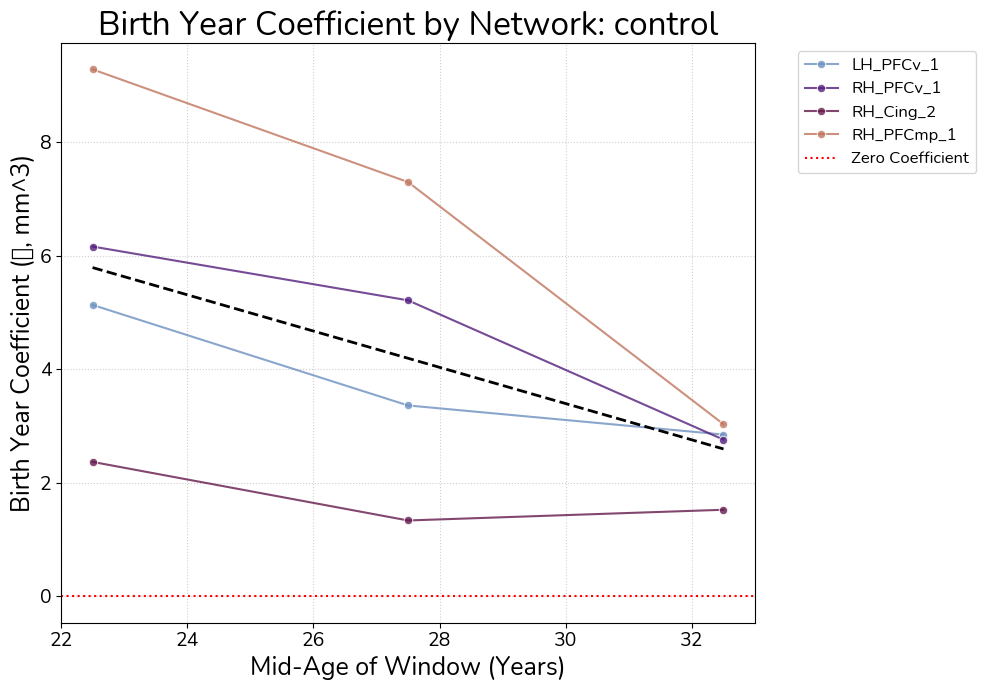

/tmp/ipykernel_369338/823162900.py:55: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Nunito.
  plt.tight_layout()
/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Nunito.
  fig.canvas.print_figure(bytes_io, **kw)


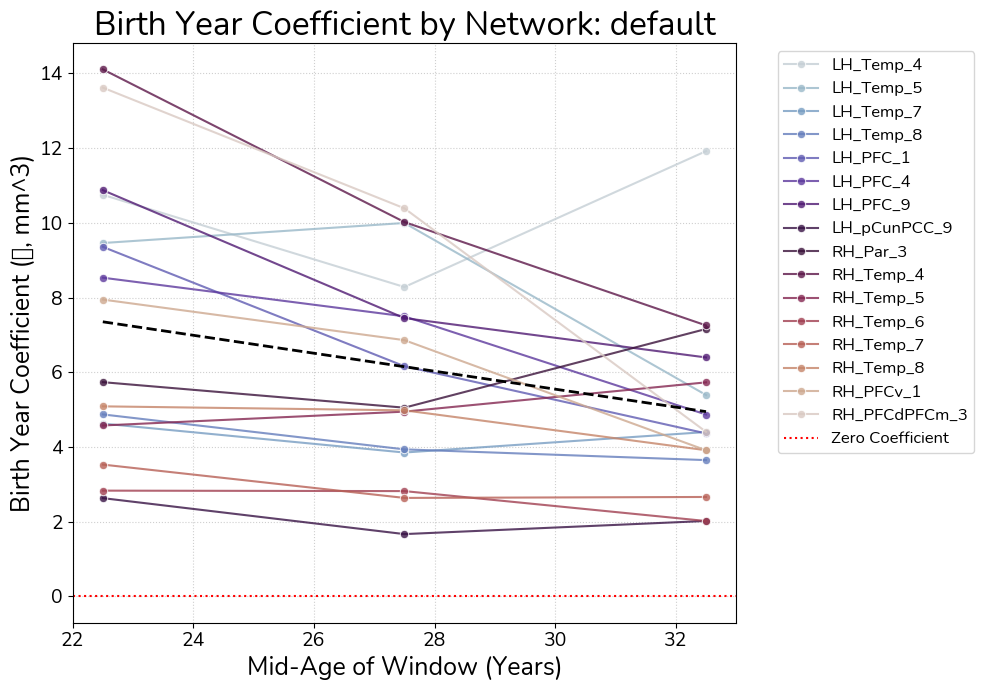

/tmp/ipykernel_369338/823162900.py:55: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Nunito.
  plt.tight_layout()
/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Nunito.
  fig.canvas.print_figure(bytes_io, **kw)


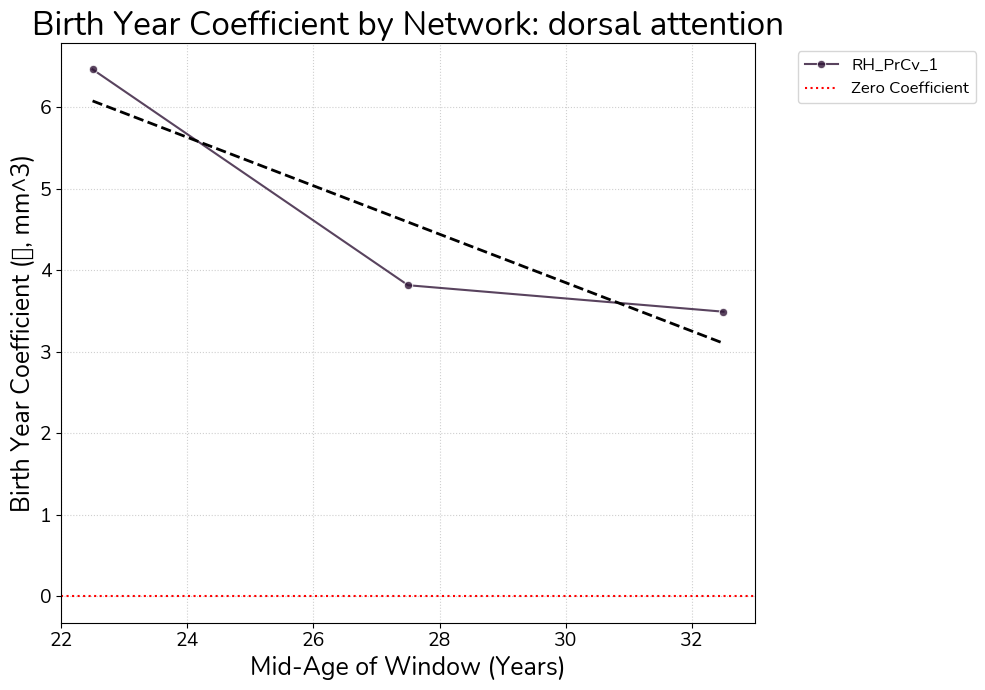

/tmp/ipykernel_369338/823162900.py:55: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Nunito.
  plt.tight_layout()
/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Nunito.
  fig.canvas.print_figure(bytes_io, **kw)


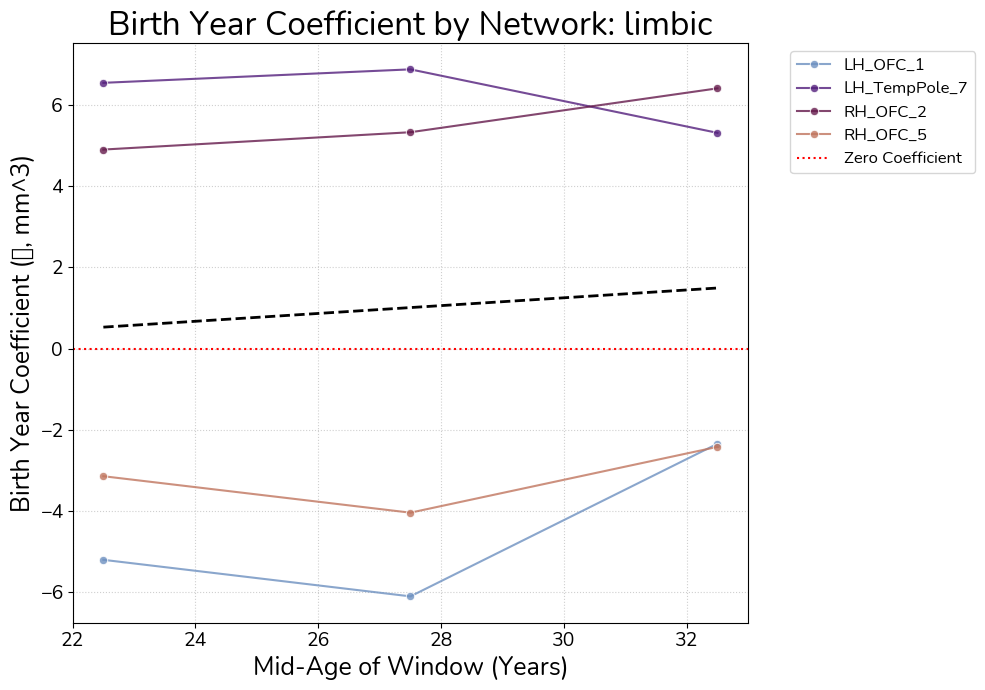

/tmp/ipykernel_369338/823162900.py:55: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Nunito.
  plt.tight_layout()
/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Nunito.
  fig.canvas.print_figure(bytes_io, **kw)


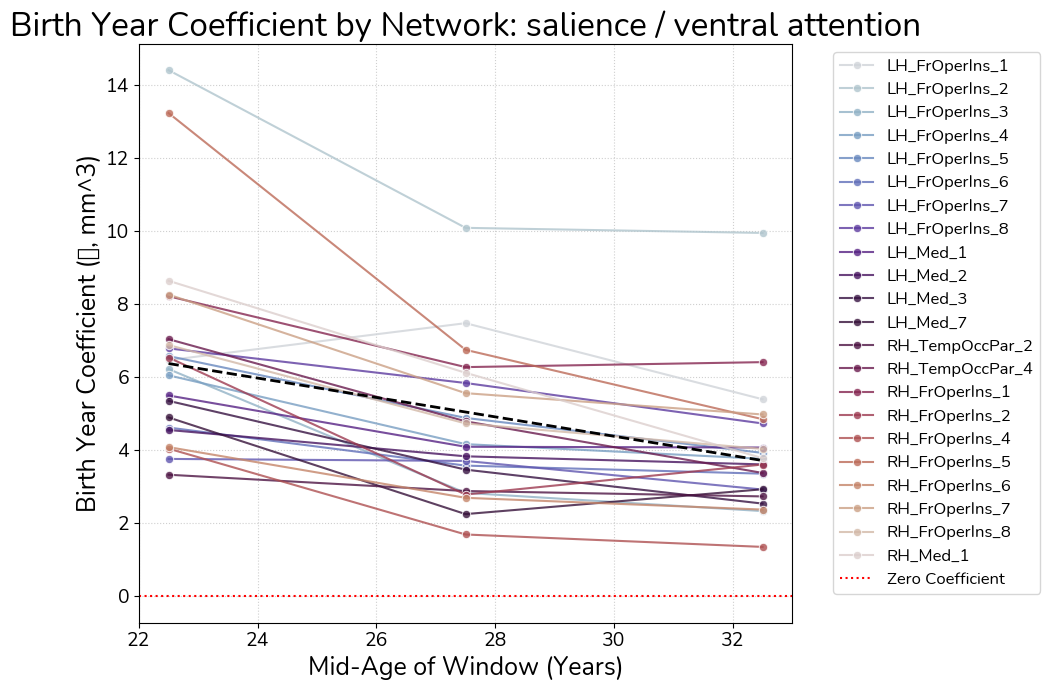

/tmp/ipykernel_369338/823162900.py:55: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Nunito.
  plt.tight_layout()
/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Nunito.
  fig.canvas.print_figure(bytes_io, **kw)


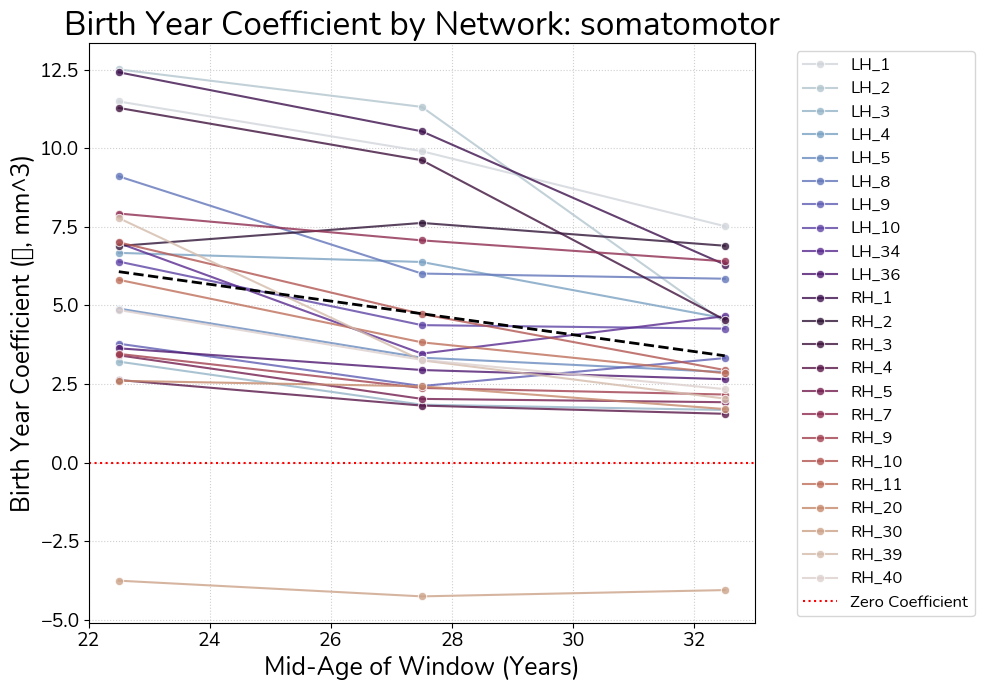

/tmp/ipykernel_369338/823162900.py:55: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Nunito.
  plt.tight_layout()
/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Nunito.
  fig.canvas.print_figure(bytes_io, **kw)


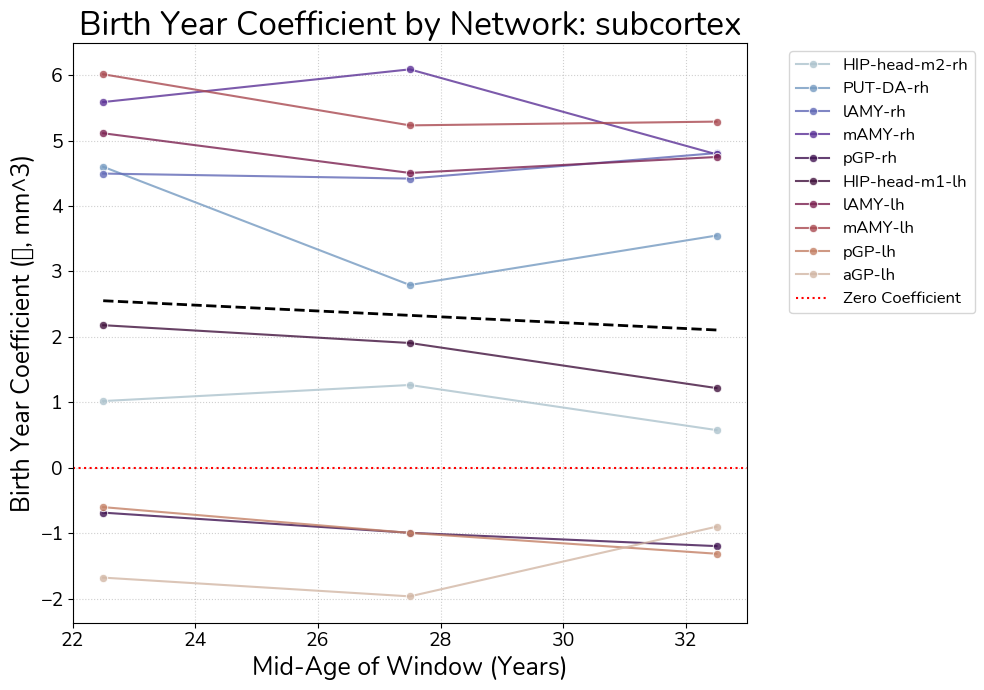

/tmp/ipykernel_369338/823162900.py:55: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Nunito.
  plt.tight_layout()
/home/gaia/Projects/legacy_data/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 946 (\N{GREEK SMALL LETTER BETA}) missing from font(s) Nunito.
  fig.canvas.print_figure(bytes_io, **kw)


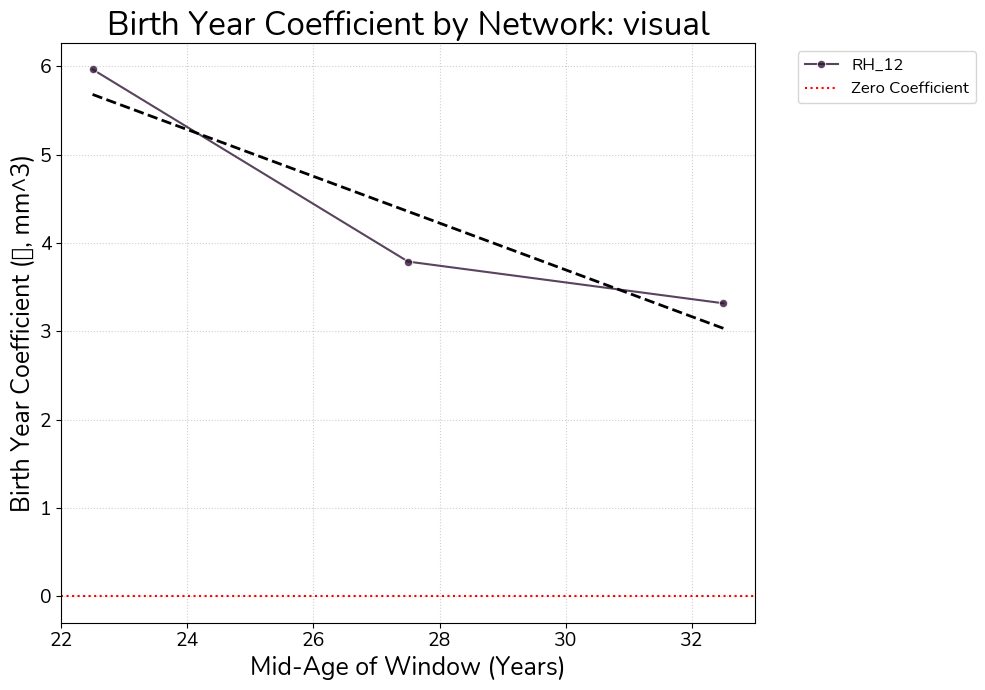

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_roi_trends_by_group(df, group_col):
    # Ensure region_name is treated as a categorical string for distinct coloring
    df = df.copy()
    df['region_name'] = (
            df['region_name']
            .astype(str)
            .str.removeprefix('7Networks_')
            .str.replace(r'H_.*?_', 'H_', regex=True)  # Finds 'H_*_' and removes '*_'
        )    
    for group_val, df_group in df.groupby(group_col):
        # We only want to plot the ROIs belonging to the current group
        # df_group already contains exactly what we need
        
        plt.figure(figsize=(10, 7))

        # Use lineplot with hue to get distinct colors per ROI
        sns.lineplot(
            data=df_group,
            x='mid_age_bin',
            y='coef',
            hue='region_name',
            marker='o',
            alpha=0.8,
            palette='twilight', 
            legend=True
        )

        # Draw the aggregate trend for the whole group (e.g., the whole network)
        sns.regplot(
            data=df_group,
            x='mid_age_bin',
            y='coef',
            scatter=False,
            ci=None,
            line_kws={'color': 'black', 'linestyle': '--', 'linewidth': 2,
                      'label': f'Global {group_val} Trend'}
        )
        
        plt.axhline(0, color='red', linestyle=':', label='Zero Coefficient')

        # Aesthetics
        plt.title(f'Birth Year Coefficient by {group_col.capitalize()}: {group_val}', fontsize=24)
        plt.xlabel('Mid-Age of Window (Years)', fontsize=18)
        plt.ylabel('Birth Year Coefficient (β, mm^3)', fontsize=18)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        
        # Place legend outside to prevent overlapping lines
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
        
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.show()

# Execution
# sig_stable_df, sig_stable_df, sig_stable_df
plot_roi_trends_by_group(sig_stable_df, 'network')
# plot_roi_trends_by_group(sig_stable_df, 'component')

Components found in sig+stable regions (20):
  1: Amygdala
  2: Hippocampus head
  3: Pallidum
  4: Putamen
  5: cingulate
  6: dorsal prefrontal cortex medial prefrontal cortex
  7: frontal operculum insula
  8: medial
  9: medial posterior prefrontal cortex
  10: orbital frontal cortex
  11: parietal
  12: precentral ventral
  13: precuneus posterior cingulate cortex
  14: prefrontal cortex
  15: somatomotor
  16: temporal
  17: temporal occipital parietal
  18: temporal pole
  19: ventral prefrontal cortex
  20: visual

Generating Component-Coded Brain Plots...


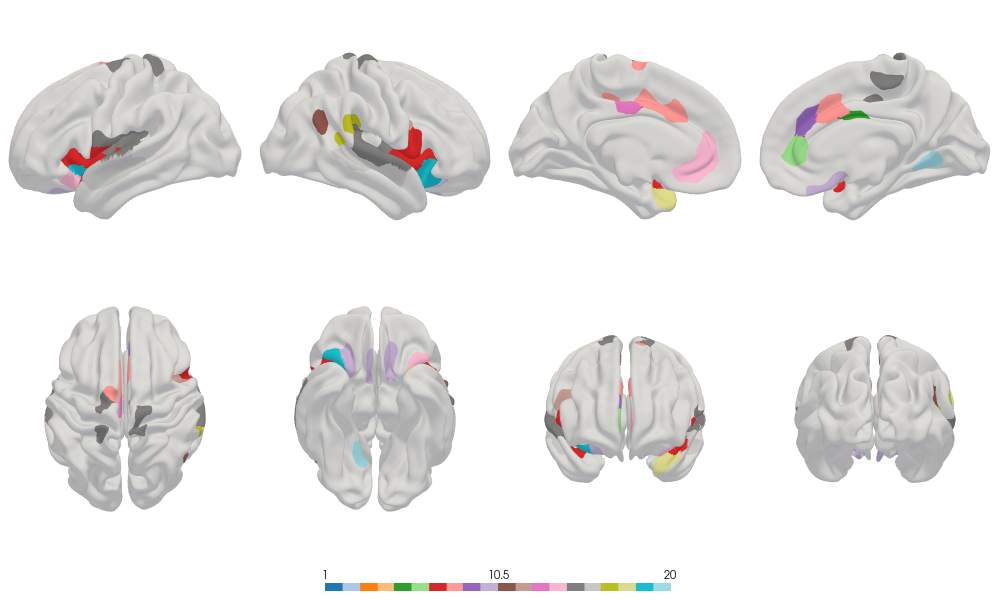

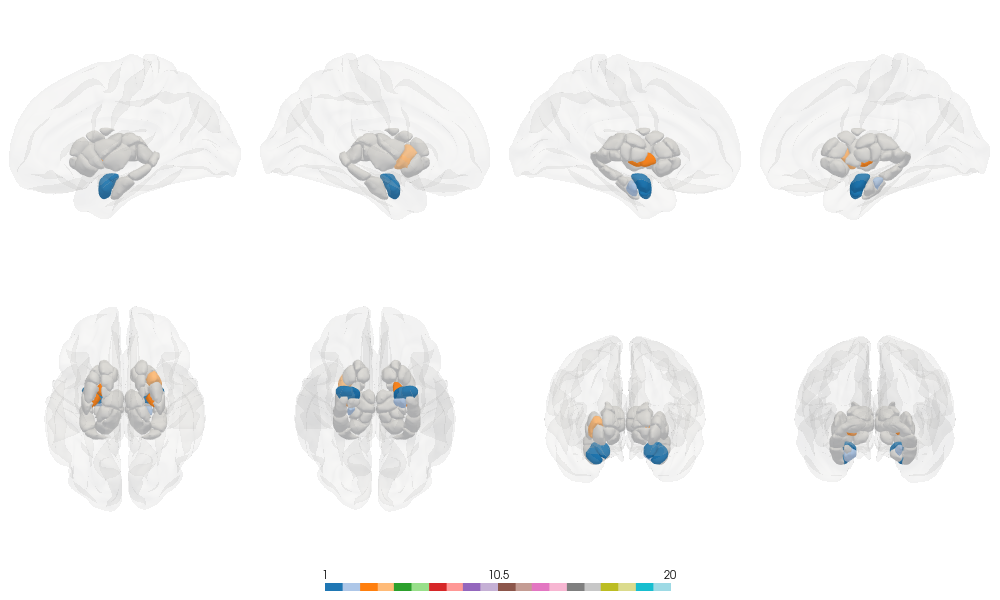


Color Legend:
   1: Amygdala                                      #1f77b4
   2: Hippocampus head                              #aec7e8
   3: Pallidum                                      #ff7f0e
   4: Putamen                                       #ffbb78
   5: cingulate                                     #2ca02c
   6: dorsal prefrontal cortex medial prefrontal cortex #98df8a
   7: frontal operculum insula                      #d62728
   8: medial                                        #ff9896
   9: medial posterior prefrontal cortex            #9467bd
  10: orbital frontal cortex                        #c5b0d5
  11: parietal                                      #8c564b
  12: precentral ventral                            #c49c94
  13: precuneus posterior cingulate cortex          #e377c2
  14: prefrontal cortex                             #f7b6d2
  15: somatomotor                                   #7f7f7f
  16: temporal                                      #c7c7c7
  17: temporal occipi

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

# --- 1. Get component for each region ---
region_info = (
    sig_stable_df.drop_duplicates('region_name')
    .set_index('region_name')[['roi_count', 'component']]
)

# Only color regions that are sig+stable in at least 1 bin
sig_stable_info = region_info[region_info['roi_count'] > 0]
unique_components = sorted(sig_stable_info['component'].dropna().unique())
n_components = len(unique_components)
comp_to_int = {comp: i + 1 for i, comp in enumerate(unique_components)}

print(f"Components found in sig+stable regions ({n_components}):")
for comp, idx in comp_to_int.items():
    print(f"  {idx}: {comp}")

# --- 2. Build plot dict: component integer for sig+stable, nan otherwise ---
plot_dict = {}
for region, row in region_info.iterrows():
    if row['roi_count'] > 0 and row['component'] in comp_to_int:
        plot_dict[region] = float(comp_to_int[row['component']])
    else:
        plot_dict[region] = np.nan

# --- 3. Categorical colormap (tab20 + tab20b for up to 40 colors) ---
all_colors = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors)
component_colors = all_colors[:n_components]
custom_cmap = ListedColormap(component_colors)

# --- 4. Split Cortical / Subcortical ---
cortical_data    = {k: v for k, v in plot_dict.items() if k.startswith('7Networks_')}
subcortical_data = {k: v for k, v in plot_dict.items() if not k.startswith('7Networks_')}

print("\nGenerating Component-Coded Brain Plots...")

# Cortical Plot (Schaefer 400)
yp.plot_cortical(
    data=cortical_data,
    atlas='schaefer400',
    vminmax=[1, n_components],
    cmap=custom_cmap,
    nan_color=(0.85, 0.85, 0.85),
    display_type='static',
)

# Subcortical Plot (Tian)
yp.plot_subcortical(
    data=subcortical_data,
    custom_atlas_path=SUB_ATLAS_PATH,
    vminmax=[1, n_components],
    cmap=custom_cmap,
    nan_color=(0.85, 0.85, 0.85),
    display_type='static',
)

# --- 5. Color legend ---
print("\nColor Legend:")
for comp, idx in comp_to_int.items():
    print(f"  {idx:>2}: {comp:<45} {mcolors.to_hex(component_colors[idx - 1])}")


In [29]:
# NO SIGNIFICANT TRENDS IN ROIS THAT ARE SIGNIFICANT AND STABLE ACROSS ALL 3 BINS

# make a regression model for each region to see if there is a trend in coef vs age bin
trend_results = []

# # only Amygdala
# roi_list = [421, 422, 448, 449]

# all rois that have roi_count == 3
roi_list = sig_stable_df['region_label'].unique().tolist()
# every value in roi list to int
roi_list = [int(roi) for roi in roi_list]

for region_of_interest in roi_list:
    region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest]
    
    if region_data.shape[0] < 2:
        continue  # Skip regions with insufficient data points

    # Fit linear regression model: coef ~ mid_age_bin
    model = smf.ols('coef ~ mid_age_bin', data=region_data).fit()
    
    trend_results.append({
        'region_label': region_of_interest,
        'slope': model.params['mid_age_bin'],
        't': model.tvalues['mid_age_bin'],
        'p': model.pvalues['mid_age_bin']
    })
trend_results_df = pd.DataFrame(trend_results)
# FDR Multiple comparison correction
from statsmodels.stats.multitest import multipletests
_, fdr_p, _, _ = multipletests(trend_results_df['p'], method='fdr_bh')
trend_results_df['fdr_p'] = fdr_p
trend_results_df = trend_results_df.sort_values(by='fdr_p')
print(trend_results_df.head())

# plot the regression lines for significant regions
significant_trends = trend_results_df[trend_results_df['fdr_p'] < 0.05]
print(f"Significant trends found in regions: {significant_trends['region_label'].tolist()}")

for _, row in significant_trends.iterrows():
    region_of_interest = row['region_label']
    region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest]
    
    plt.figure(figsize=(5, 3))
    sns.regplot(
        data=region_data,
        x='mid_age_bin',
        y='coef',
        ci=None,
        line_kws={'color': 'red'}
    )
    plt.title(f'Trend in Birth Year Coefficient vs Age Bin for Region {region_of_interest}')
    plt.xlabel('Age Bin')
    plt.ylabel('Birth Year Coefficient')
    plt.xticks(rotation=45)
    plt.grid()
    plt.tight_layout()
    plt.show()

    region_label     slope         t         p     fdr_p
0             32 -0.396706 -8.523922  0.074346  0.452312
4             36 -0.202076 -3.165296  0.194808  0.452312
15           102 -0.126309 -2.659710  0.228948  0.452312
9             67 -0.098212 -4.261923  0.146720  0.452312
13           100 -0.228539 -2.672839  0.227917  0.452312
Significant trends found in regions: []


In [30]:
print(combined_df.columns)
combined_df['volume/tiv'] = combined_df['volume_mm3'] / (combined_df['tiv'] * 1000)
# convert volume/tiv to percentage
combined_df['volume/tiv'] *= 100

Index(['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3',
       'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob',
       'gm_volume_cm3', 'protocol', 'source', 'birth_year', 'unnamed: 0',
       'atlas_name', 'scan_time', 'age_at_scan', 'weight', 'directory_path',
       'estimated_critical_info', 'scan_date', 'file_path', 'scan_year',
       'classification_label', 'id', 'age_bin', 'ps_weight'],
      dtype='str')


In [31]:
print(combined_df.columns)


Index(['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3',
       'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob',
       'gm_volume_cm3', 'protocol', 'source', 'birth_year', 'unnamed: 0',
       'atlas_name', 'scan_time', 'age_at_scan', 'weight', 'directory_path',
       'estimated_critical_info', 'scan_date', 'file_path', 'scan_year',
       'classification_label', 'id', 'age_bin', 'ps_weight', 'volume/tiv'],
      dtype='str')


In [32]:
# plot setting: 
main_title_fontsize = 80
subtitle_fontsize = 60
axis_label_fontsize = 74
ticks_fontsize = 58
legend_fontsize = 32

# plot the trend by roi, color code by age_bin
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import matplotlib.font_manager as fm

# 1. Point to the file you just downloaded
font_path = '/home/gaia/Downloads/Nunito/static/Nunito-Regular.ttf' # Example path
fm.fontManager.addfont(font_path)

# 2. Set it globally
plt.rcParams['font.family'] = 'Nunito'
# Set Nunito as the primary sans-serif font
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Nunito',  'sans-serif']


# --- 1. Identify the ROIs of interest ---
target_rois = sig_stable_df['region_label'].astype(str).str.strip().unique().tolist()
target_rois = ['421']

if isinstance(combined_df, list):
    combined_df = pd.concat(combined_df) if isinstance(combined_df[0], pd.DataFrame) else pd.DataFrame(combined_df)

# --- 2. Clean and Prepare Data ---
combined_df['region_label'] = combined_df['region_label'].astype(str).str.strip()
combined_df['age_bin'] = combined_df['age_bin'].astype(str).str.strip()

# --- 3. Filter ---
target_bins = ['(20, 25]', '(25, 30]', '(30, 35]']

plot_data = combined_df[
    (combined_df['region_label'].isin(target_rois)) & 
    (combined_df['age_bin'].isin(target_bins))  
    & (combined_df['volume/tiv'] > 0.03) 
    & (combined_df['volume/tiv'] < 0.10)
].copy()

# --- 4. Diagnostic Print ---
print(f"Final plot_data row count: {len(plot_data)}")

# --- 5. Iterate and Plot ---
for roi in target_rois:
    roi_data = plot_data[plot_data['region_label'] == roi]
    
    if roi_data.empty:
        continue
        
    plt.figure(figsize=(32, 20))
    
    # Create the scatter plot using normalized_gmv
    sns.scatterplot(
        data=roi_data,
        x='birth_year',
        y='volume/tiv',  # Original GMV for raw visualization
        hue='age_bin',
        hue_order=target_bins, 
        palette='viridis',     
        alpha=0.6,
        edgecolor=None,
        # dot size:
        s=100
    )
    
    # Add regression lines for each bin
    # We plot the regression on the normalized values to see the corrected trend
    sns.regplot(
        data=roi_data, 
        x='birth_year', 
        y='volume/tiv',  # Original GMV for raw visualization
        scatter=False, 
        color='black', 
        line_kws={'linestyle': '--', 'alpha': 0.5}
    )


    plt.title(f'RL Amygdala: Volume along Birth Year \nMean Birth Year Coefficient = 4.46', fontsize=main_title_fontsize)
    plt.xlabel('Birth Year', fontsize=axis_label_fontsize)
    plt.ylabel('ROI Volume/TIV (%)', fontsize=axis_label_fontsize)
    plt.xticks(fontsize=ticks_fontsize)
    plt.yticks(fontsize=ticks_fontsize)
    plt.legend(title='Age Bin', fontsize=ticks_fontsize, loc='upper left', title_fontsize=ticks_fontsize, markerscale=4)
    plt.tight_layout()
    
    plt.show()

Final plot_data row count: 0


In [33]:
# # # plot the trend by roi, color code by age_bin
# # separate regression line per age_bin

# # --- 1. Identify the ROIs of interest ---
# target_rois = sig_stable_df['region_label'].astype(str).str.strip().unique().tolist()

# if isinstance(combined_df, list):
#     combined_df = pd.concat(combined_df) if isinstance(combined_df[0], pd.DataFrame) else pd.DataFrame(combined_df)

# # --- 2. Clean and Prepare Data ---
# combined_df['region_label'] = combined_df['region_label'].astype(str).str.strip()
# combined_df['age_bin'] = combined_df['age_bin'].astype(str).str.strip()

# # --- 3. Filter ---
# target_bins = ['(20, 25]', '(25, 30]', '(30, 35]']

# plot_data = combined_df[
#     (combined_df['region_label'].isin(target_rois)) & 
#     (combined_df['age_bin'].isin(target_bins))
# ].copy()

# # --- 4. Diagnostic Print ---
# print(f"Final plot_data row count: {len(plot_data)}")

# # --- 5. Iterate and Plot ---
# # Define colors manually to ensure scatter and regression lines match
# palette_colors = sns.color_palette('viridis', len(target_bins))
# color_map = dict(zip(target_bins, palette_colors))

# for roi in target_rois:
#     roi_data = plot_data[plot_data['region_label'] == roi]
    
#     if roi_data.empty:
#         continue
        
#     plt.figure(figsize=(10, 6))
    
#     # Create the scatter plot
#     sns.scatterplot(
#         data=roi_data,
#         x='birth_year',
#         y='volume_mm3',
#         hue='age_bin',
#         hue_order=target_bins, 
#         palette=color_map, 
#         alpha=0.4,
#         edgecolor=None
#     )
    
#     # --- FIX: Loop through bins to add individual regression lines ---
#     for bin_name in target_bins:
#         bin_subset = roi_data[roi_data['age_bin'] == bin_name]
        
#         # Only plot if we have enough data points for a regression
#         if len(bin_subset) > 2:
#             sns.regplot(
#                 data=bin_subset, 
#                 x='birth_year', 
#                 y='volume_mm3',
#                 scatter=False, 
#                 ci=None, # Set to 95 if you want confidence intervals
#                 color=color_map[bin_name], # Matches the scatter color
#                 line_kws={'linewidth': 2.5}
#             )

#     plt.title(f'GMV vs Birth Year per Age Bin\nROI: {roi}')
#     plt.xlabel('Birth Year')
#     plt.ylabel('GMV (ROI Volume in mm³)')
    
#     # Adjust legend to be outside the plot
#     plt.legend(title='Age Bin', bbox_to_anchor=(1.05, 1), loc='upper left')
#     plt.grid(True, linestyle=':', alpha=0.5)
#     plt.tight_layout()
    
#     plt.show()

In [34]:
# fdr_p has only 3 numbers after decimal 
df_to_export = birth_year_coef_df.copy()
df_to_export['fdr_p'] = df_to_export['fdr_p'].round(3)
df_to_export = df_to_export[df_to_export['sig_stab'] == True]


#keep only the columns region_name age_bin coef t fdr_p roi_count network
df_to_export = df_to_export[['region_name', 'age_bin', 'coef', 't', 'fdr_p', 'roi_count', 'network']]

df_to_export = df_to_export.sort_values(by=['region_name', 'age_bin'])